# Instalando e importando bibliotecas necessárias


In [ ]:
!pip install scikit-posthocs

In [ ]:
# Manipulação de Dados e Análise
import pandas as pd
import numpy as np
import time
import os
from collections import Counter

# Mapa de Calor
import folium
from folium.plugins import HeatMap

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Modelagem
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Métricas, Estatística e Utilitários
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
from scipy import stats
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import warnings

# Configurações Globais de Reprodutibilidade
N_FOLDS = 5
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")

# Carregando o Dataset

In [ ]:
data = pd.read_csv('Airbnb_Open_Data.csv', engine='python')

data.head()

,name,summary,space,description,experiences_offered,neighborhood_overview,notes,transit,access,interaction,...,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price
0,Private room + garden 2mins walk to everywhere.,"2 rooms new apartment, your stay with private ...","2 bedroom apartment, you got one of the room a...","2 rooms new apartment, your stay with private ...",none,NaN,NaN,NaN,NaN,NaN,...,f,moderate,f,f,7,5,2,0,NaN,$58.00
1,"On the Beachfront, next to cafes and restaurants.",Beachfront balcony and next to cafes and resta...,"Happy to accommodate your requests, as best we...",Beachfront balcony and next to cafes and resta...,none,"Comfortable, relaxed, beachy with ample cafes ...",NaN,The bus stop is within 50m of the front door. ...,NaN,NaN,...,f,strict_14_with_grace_period,f,f,2,1,1,0,0.15,$125.00
2,Room in Camperdown,"Excellent location! Close to superb bars, cafe...",NaN,"Excellent location! Close to superb bars, cafe...",none,NaN,NaN,NaN,NaN,NaN,...,f,flexible,f,f,1,0,1,0,NaN,$99.00
3,Beautiful room in summer hill,"A Typical inner west sydney share house, you w...","Living room, out back balcony, kitchen, bathro...","A Typical inner west sydney share house, you w...",none,"Summer hill, is a gorgeous and quiet inner we...","Make yourself at home, enjoy a typical inner w...","Train is 5 minutes walking distance from house,",NaN,"I will be away in Europe, so won’t be able to ...",...,f,strict_14_with_grace_period,f,f,1,0,1,0,NaN,$99.00
4,2 Bedroom Apartment in Kensington.,2 Bedroom Loft Apartment in a small complex. W...,NaN,2 Bedroom Loft Apartment in a small complex. W...,none,NaN,NaN,NaN,NaN,NaN,...,f,flexible,f,f,1,1,0,0,0.05,$125.00


# **Análise Exploratória de Dados (EDA)**

## Descrição das Colunas


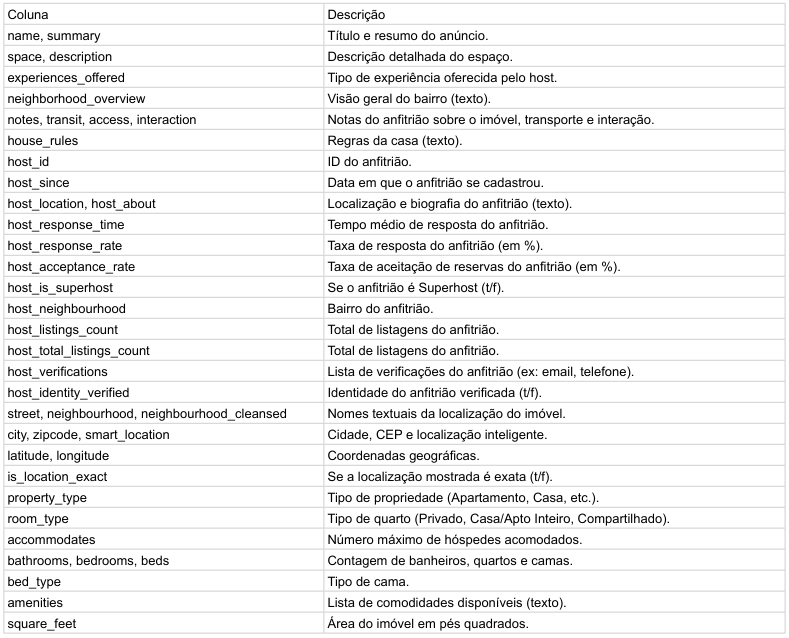

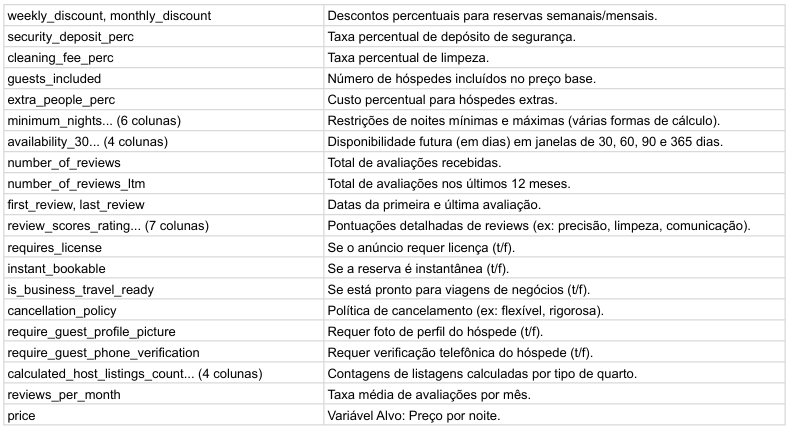

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9838 entries, 0 to 9837
Data columns (total 83 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   name                                          9838 non-null   object 
 1   summary                                       9838 non-null   object 
 2   space                                         7184 non-null   object 
 3   description                                   9838 non-null   object 
 4   experiences_offered                           9838 non-null   object 
 5   neighborhood_overview                         6400 non-null   object 
 6   notes                                         4300 non-null   object 
 7   transit                                       6469 non-null   object 
 8   access                                        5946 non-null   object 
 9   interaction                                   5957 non-null   o

# **Análise Exploratória**

## Preparação do ambiente e limpeza inicial


In [ ]:
Y_col = 'price'
df_clean = data.copy()

def clean_price(price_str):
    if isinstance(price_str, str):
        return float(price_str.replace('$', '').replace(',', ''))
    return float(price_str)

def clean_percentage(perc_str):
    if isinstance(perc_str, str):
        return float(perc_str.replace('%', '')) / 100
    return float(perc_str)

df_clean[Y_col] = df_clean[Y_col].apply(clean_price)
if 'host_response_rate' in df_clean.columns:
    df_clean['host_response_rate'] = df_clean['host_response_rate'].apply(clean_percentage)

date_cols = ['host_since', 'first_review', 'last_review']
for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

print("Limpeza inicial de dados concluída: 'price', 'host_response_rate' e colunas de data foram tratadas.")

Limpeza inicial de dados concluída: 'price', 'host_response_rate' e colunas de data foram tratadas.


In [ ]:
cols_to_drop = [
    'experiences_offered',
    'requires_license',
    'host_acceptance_rate',

    'name',
    'summary',
    'space',
    'description',
    'neighborhood_overview',
    'notes',
    'access',
    'transit',
    'interaction',
    'house_rules',
    'street',
    'neighbourhood',
    'neighbourhood_cleansed',
    'city'
]

print(f"\nRemovendo {len(cols_to_drop)} colunas desnecessárias (texto e variância zero)...")
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

print("Colunas removidas com sucesso!")
print(f"Número de colunas restantes: {df_clean.shape[1]}")


Removendo 17 colunas desnecessárias (texto e variância zero)...
Colunas removidas com sucesso!
Número de colunas restantes: 66


## Visão Geral e Integridade de Dados

In [ ]:
print("Visão Geral do Dataset")
df_clean.info(memory_usage='deep')

print("\n\n--- Estatísticas Descritivas das Features Numéricas ---")
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print(df_clean.describe())

print("\n\n--- Análise de Valores Ausentes (Colunas com mais de 1% de ausência) ---")
missing_vals = df_clean.isnull().sum()
missing_perc = (missing_vals / len(df_clean)) * 100
missing_report = pd.DataFrame({'Contagem Ausente': missing_vals, 'Percentual Ausente (%)': missing_perc})
print(missing_report[missing_report['Percentual Ausente (%)'] > 1].sort_values(by='Percentual Ausente (%)', ascending=False))

Visão Geral do Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9838 entries, 0 to 9837
Data columns (total 66 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   host_id                                       9838 non-null   int64         
 1   host_since                                    9838 non-null   datetime64[ns]
 2   host_location                                 9830 non-null   object        
 3   host_about                                    5475 non-null   object        
 4   host_response_time                            5272 non-null   object        
 5   host_response_rate                            5272 non-null   float64       
 6   host_is_superhost                             9838 non-null   object        
 7   host_neighbourhood                            6923 non-null   object        
 8   host_listings_count                          

## Análise da Variável Alvo (price)


--- Resumo Estatístico da Variável Alvo: Price ---
count   9838.00
mean     214.68
std      250.72
min       52.00
25%       89.00
50%      146.00
75%      236.00
max     4656.00
Name: price, dtype: float64


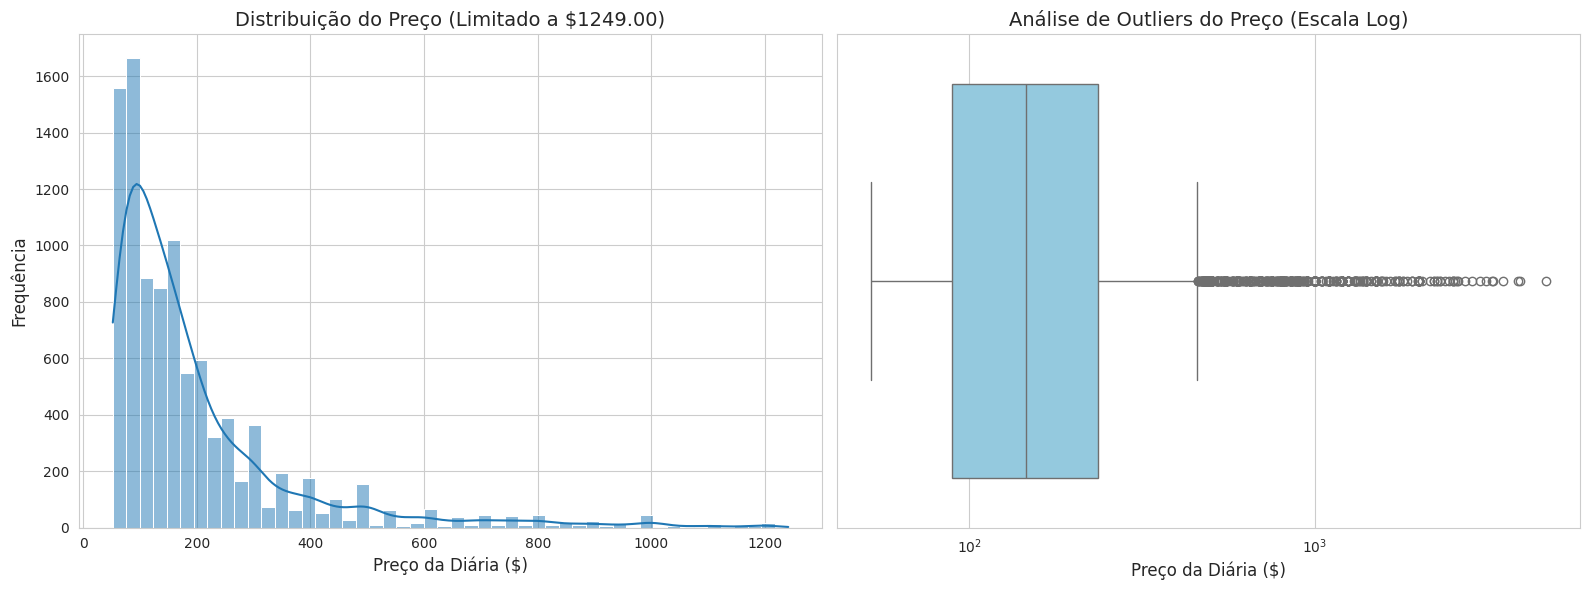

In [ ]:
price_summary = df_clean[Y_col].describe()
print("\n--- Resumo Estatístico da Variável Alvo: Price ---")
print(price_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

price_cap = df_clean[Y_col].quantile(0.99)

sns.histplot(
    df_clean[Y_col][df_clean[Y_col] < price_cap],
    kde=True,
    bins=50,
    ax=axes[0]
)
axes[0].set_title(f'Distribuição do Preço (Limitado a ${price_cap:.2f})', fontsize=14)
axes[0].set_xlabel('Preço da Diária ($)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)

sns.boxplot(
    x=df_clean[Y_col],
    color='skyblue',
    ax=axes[1]
)
axes[1].set_title('Análise de Outliers do Preço (Escala Log)', fontsize=14)
axes[1].set_xlabel('Preço da Diária ($)', fontsize=12)
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

# Análise de Normalidade (Variável Alvo)

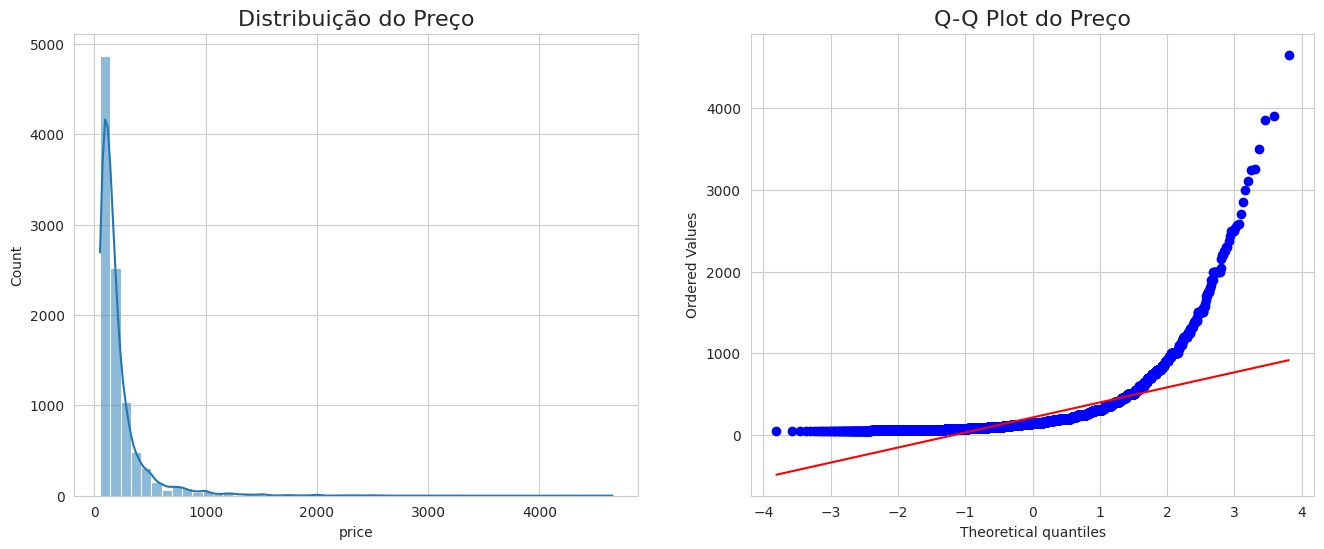


Teste de Shapiro-Wilk para 'price' (amostra de 4999 pontos):
P-valor: 0.0000000000

Conclusão: O P-valor é menor que 0.05, portanto a hipótese nula de normalidade é rejeitada.
A distribuição da variável 'price' NÃO é normal.


In [ ]:
def clean_price(price_str):
    if isinstance(price_str, str):
        return float(price_str.replace('$', '').replace(',', ''))
    return float(price_str)
price_data = df_clean['price'].apply(clean_price).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(price_data, kde=True, ax=axes[0], bins=50)
axes[0].set_title('Distribuição do Preço', fontsize=16)

stats.probplot(price_data, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot do Preço', fontsize=16)
plt.show()

sample_size = min(len(price_data), 4999)
shapiro_stat, shapiro_p_value = stats.shapiro(price_data.sample(sample_size, random_state=RANDOM_STATE))
print(f"\nTeste de Shapiro-Wilk para 'price' (amostra de {sample_size} pontos):")
print(f"P-valor: {shapiro_p_value:.10f}")

if shapiro_p_value < 0.05:
    print("\nConclusão: O P-valor é menor que 0.05, portanto a hipótese nula de normalidade é rejeitada.")
    print("A distribuição da variável 'price' NÃO é normal.")
else:
    print("\nConclusão: O P-valor é maior que 0.05, não há evidência para rejeitar a hipótese nula de normalidade.")

## Análise de Correlação Numérica

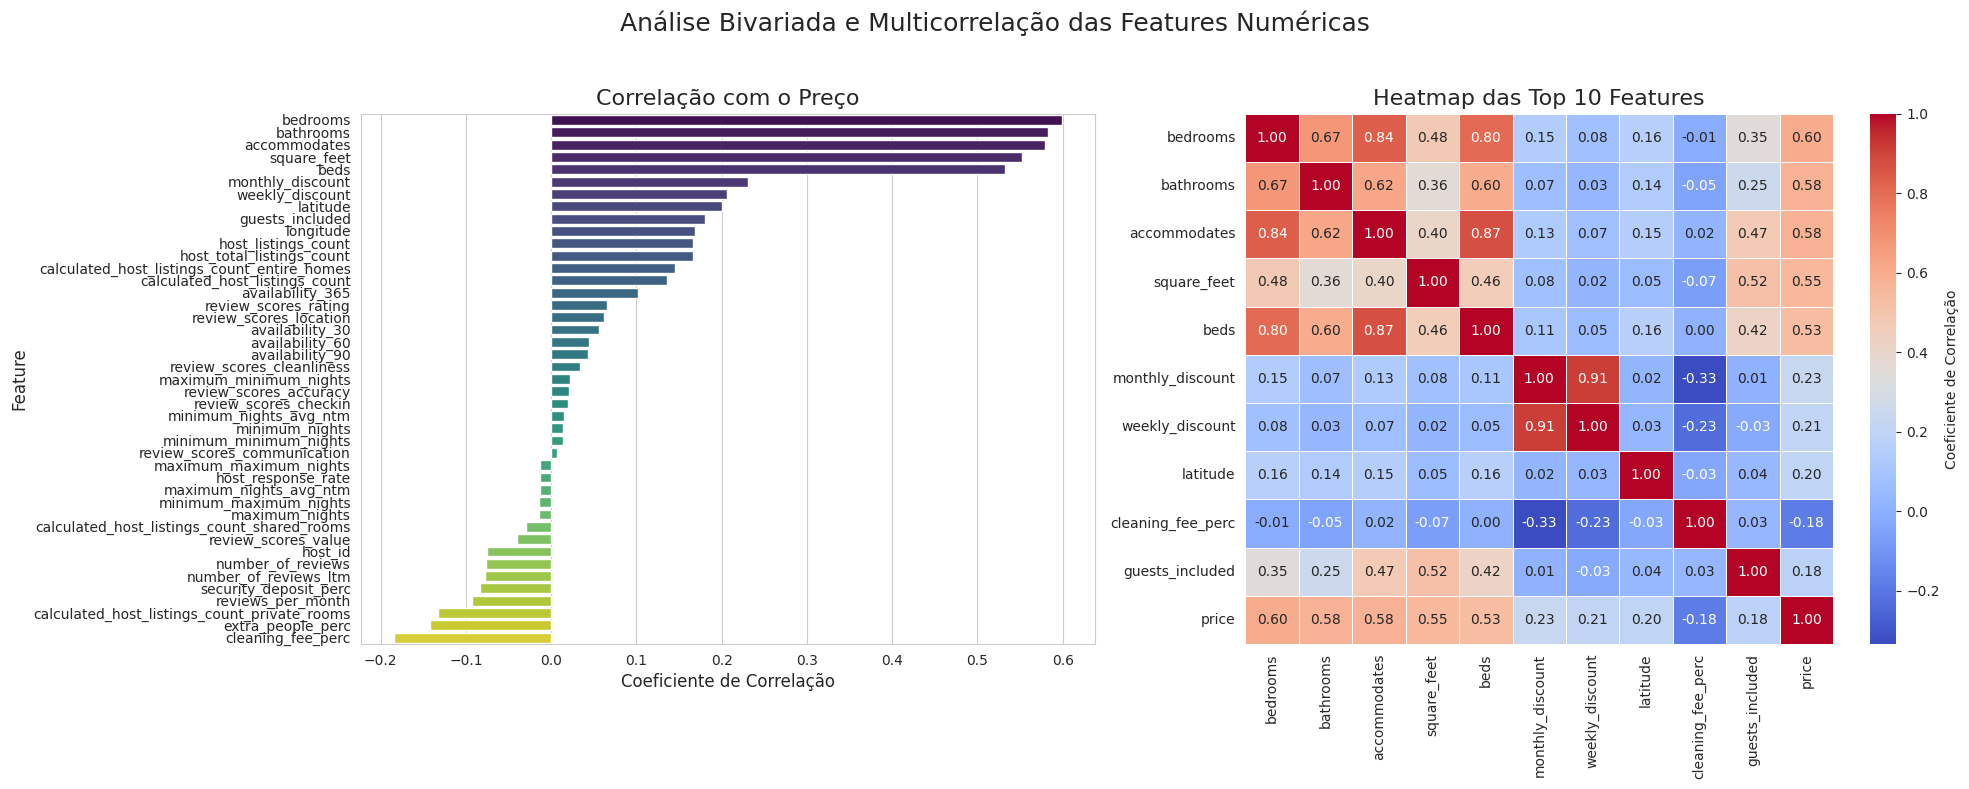

In [ ]:
numerical_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
if Y_col in numerical_cols:
    correlation_matrix = df_clean[numerical_cols].corr()
    price_correlation = correlation_matrix[Y_col].sort_values(ascending=False).drop(Y_col)
else:
    print(f"ERRO: Coluna alvo '{Y_col}' não encontrada ou não é numérica.")

top_corr_features = price_correlation.abs().nlargest(10).index.tolist() + [Y_col]
top_corr_matrix = df_clean[top_corr_features].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(
    x=price_correlation.values,
    y=price_correlation.index,
    hue=price_correlation.index,
    palette='viridis',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Correlação com o Preço', fontsize=16)
axes[0].set_xlabel('Coeficiente de Correlação', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)

sns.heatmap(
    top_corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Coeficiente de Correlação'},
    ax=axes[1]
)
axes[1].set_title('Heatmap das Top 10 Features', fontsize=16)

fig.suptitle('Análise Bivariada e Multicorrelação das Features Numéricas', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Análise de Variância

In [ ]:
print("Análise de Variância das Features")

unique_counts = df_clean.nunique()
zero_variance_cols = unique_counts[unique_counts == 1].index.tolist()
low_variance_cols = unique_counts[(unique_counts > 1) & (unique_counts <= 3)].index.tolist()

if zero_variance_cols:
    print("\nFeatures com Variância Zero (constantes):")
    print(zero_variance_cols)

if low_variance_cols:
    print("\nFeatures com Baixa Variância (2 ou 3 valores únicos):")
    print(low_variance_cols)

Análise de Variância das Features

Features com Variância Zero (constantes):
['is_business_travel_ready']

Features com Baixa Variância (2 ou 3 valores únicos):
['host_is_superhost', 'host_identity_verified', 'is_location_exact', 'room_type', 'instant_bookable', 'require_guest_profile_picture', 'require_guest_phone_verification']


## Análise de alta cardinalidade - comodidades (amenities)

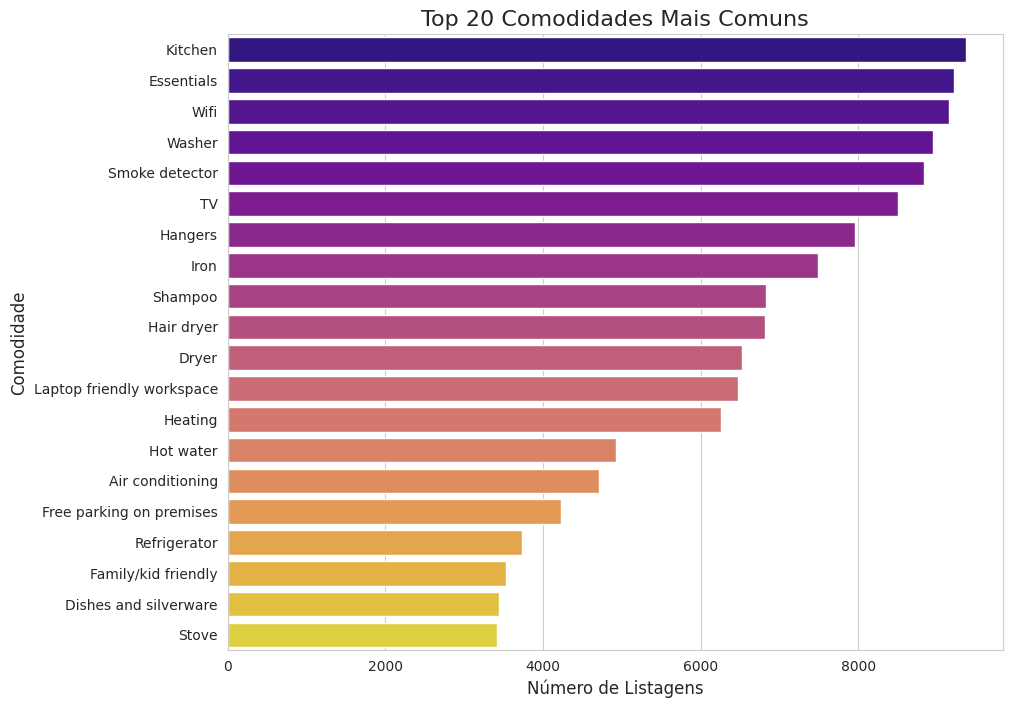

In [ ]:
amenities_list = df_clean['amenities'].str.replace('[{}"\']', '', regex=True).dropna().tolist()
all_amenities = Counter([item.strip() for sublist in [s.split(',') for s in amenities_list] for item in sublist if item.strip()])

top_amenities = pd.DataFrame(all_amenities.most_common(20), columns=['Comodidade', 'Contagem'])

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_amenities,
    x='Contagem',
    y='Comodidade',
    hue='Comodidade',
    palette='plasma',
    orient='h',
    legend=False
)
plt.title('Top 20 Comodidades Mais Comuns', fontsize=16)
plt.xlabel('Número de Listagens', fontsize=12)
plt.ylabel('Comodidade', fontsize=12)
plt.show()

## Análise Geoespacial - Distribuição dos Imóveis

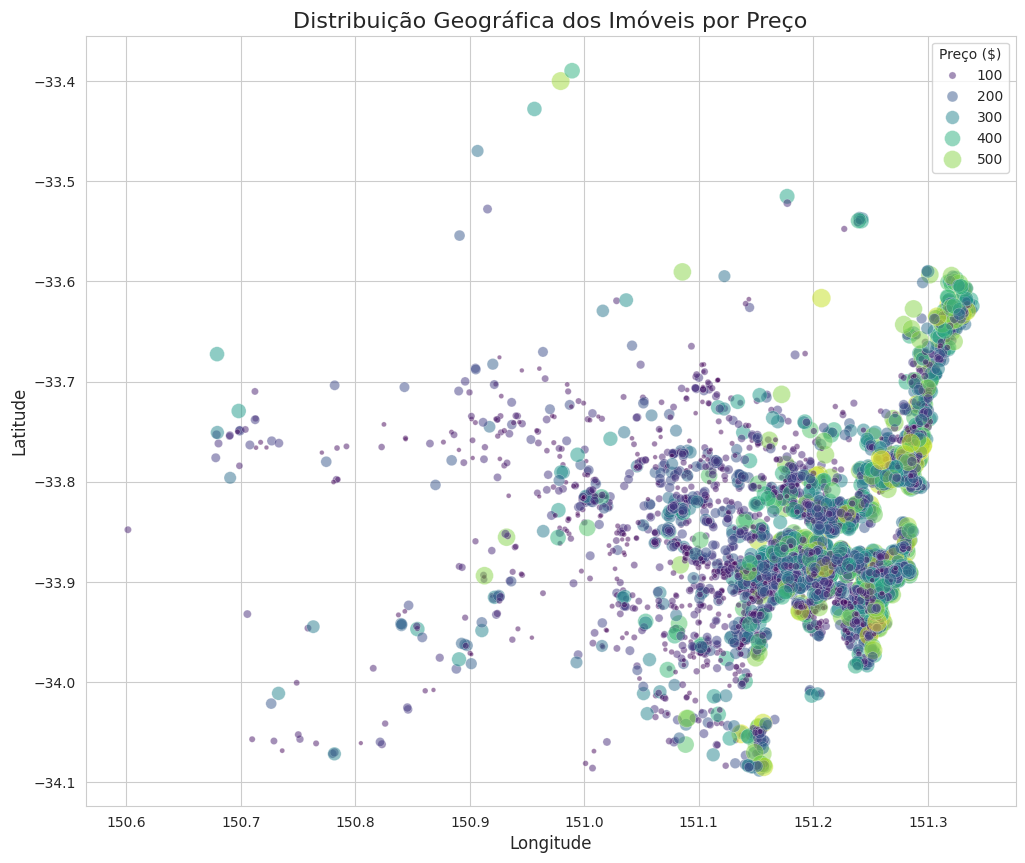

In [ ]:
geo_cols = ['latitude', 'longitude']
if all(col in df_clean.columns for col in geo_cols):
    price_cap_map = df_clean[Y_col].quantile(0.95)
    df_map = df_clean[df_clean[Y_col] < price_cap_map]

    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        data=df_map,
        x='longitude',
        y='latitude',
        hue=Y_col,
        palette='viridis',
        size=Y_col,
        sizes=(10, 200),
        alpha=0.5,
        legend='auto'
    )
    plt.title('Distribuição Geográfica dos Imóveis por Preço', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.legend(title='Preço ($)')
    plt.show()

# **Mapa de Calor Geoespacial do Preço**

In [ ]:
df_map = data[['latitude', 'longitude', 'price']].copy()
df_map.dropna(inplace=True)

def clean_price(price_str):
    if isinstance(price_str, str):
        return float(price_str.replace('$', '').replace(',', ''))
    return float(price_str)
df_map['price'] = df_map['price'].apply(clean_price)

heat_data = df_map[['latitude', 'longitude', 'price']].values.tolist()

center_lat = df_map['latitude'].median()
center_lon = df_map['longitude'].median()

m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles='cartodbpositron')

HeatMap(heat_data, radius=15, blur=20).add_to(m)

os.makedirs('results', exist_ok=True)
map_filename = 'results/mapa_calor_preco.html'
m.save(map_filename)

print(f"Mapa de Calor interativo salvo em: {map_filename}")

Mapa de Calor interativo salvo em: results/mapa_calor_preco.html


## Análise Temporal - Crescimento de Anfitriões na Plataforma

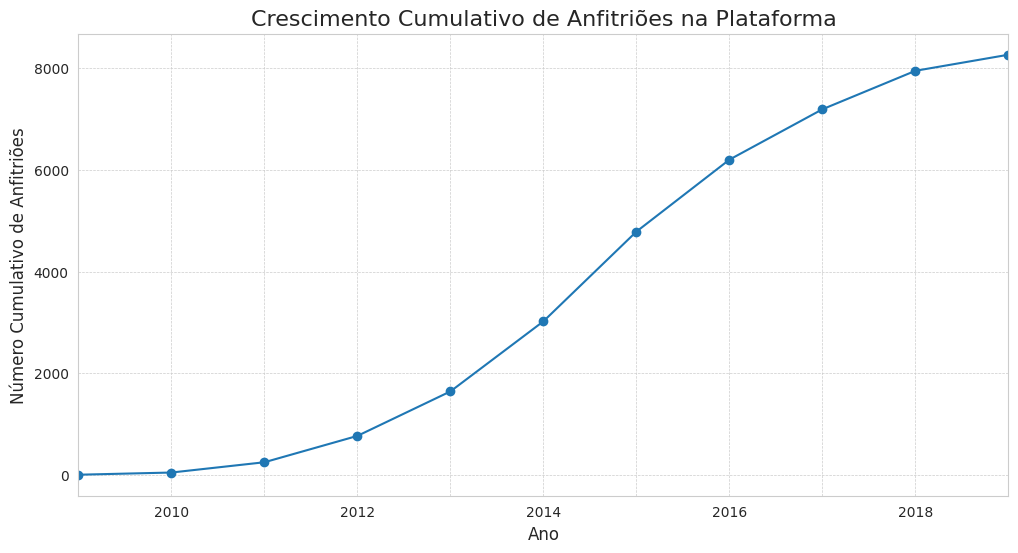

In [ ]:
if 'host_since' in df_clean.columns:
    hosts_over_time = df_clean[['host_id', 'host_since']].dropna().drop_duplicates(subset='host_id')
    hosts_over_time = hosts_over_time.set_index('host_since').resample('YE').size().cumsum()

    plt.figure(figsize=(12, 6))
    hosts_over_time.plot(kind='line', marker='o')
    plt.title('Crescimento Cumulativo de Anfitriões na Plataforma', fontsize=16)
    plt.xlabel('Ano', fontsize=12)
    plt.ylabel('Número Cumulativo de Anfitriões', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

# Tratamento de valores ausentes

## Identificação de Colunas para Imputação

In [ ]:
df_imputed = df_clean.copy()

missing_report = df_imputed.isnull().sum()
cols_with_missing = missing_report[missing_report > 0].index.tolist()

numerical_missing = [col for col in cols_with_missing if df_imputed[col].dtype in ['int64', 'float64']]
categorical_missing = [col for col in cols_with_missing if df_imputed[col].dtype in ['object', 'category']]

## Análise e Imputação para Dados NUMÉRICOS Ausentes

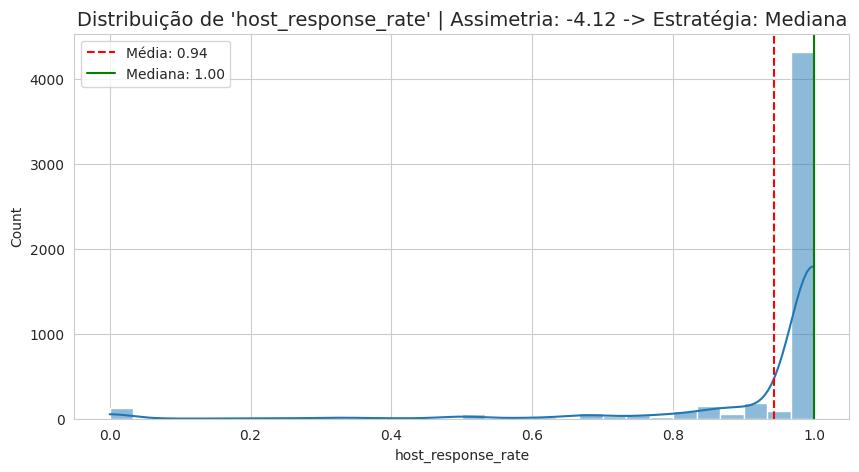

Coluna 'host_response_rate' imputada com a Mediana (1.00).


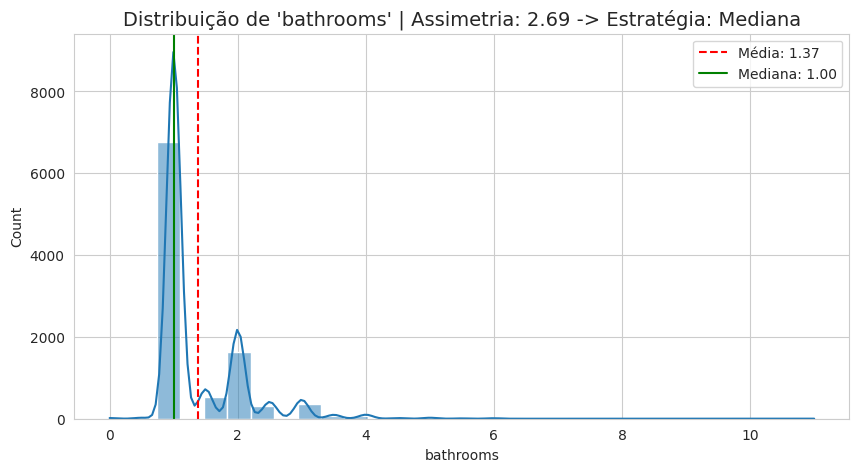

Coluna 'bathrooms' imputada com a Mediana (1.00).


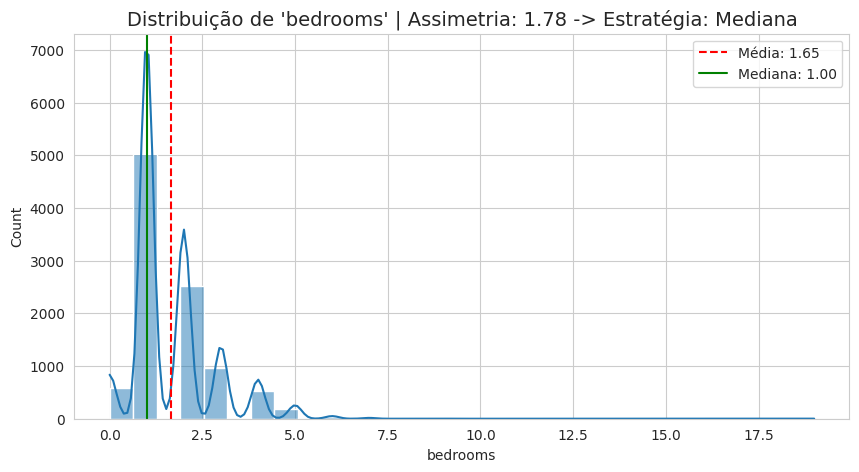

Coluna 'bedrooms' imputada com a Mediana (1.00).


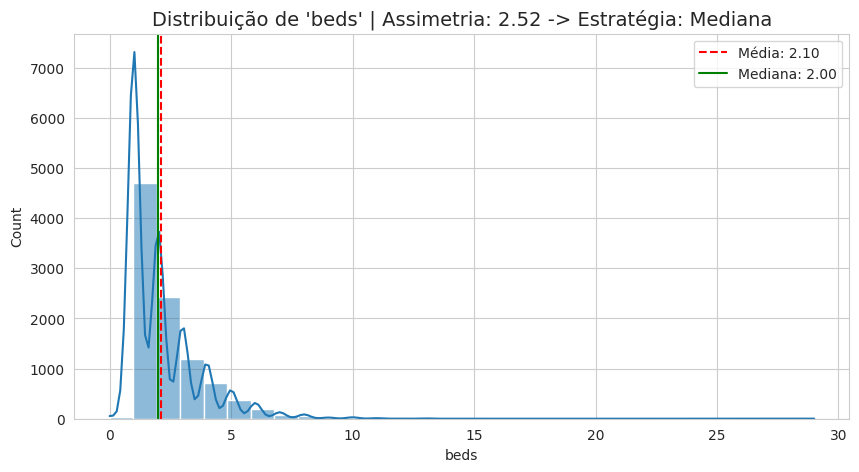

Coluna 'beds' imputada com a Mediana (2.00).


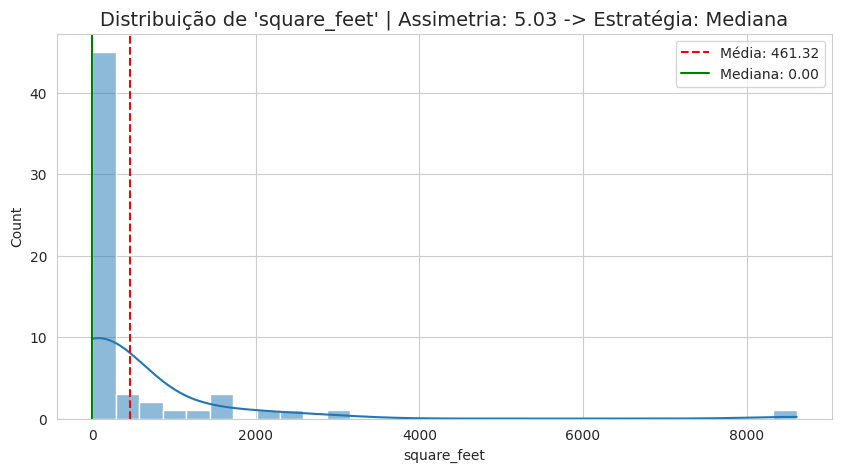

Coluna 'square_feet' imputada com a Mediana (0.00).


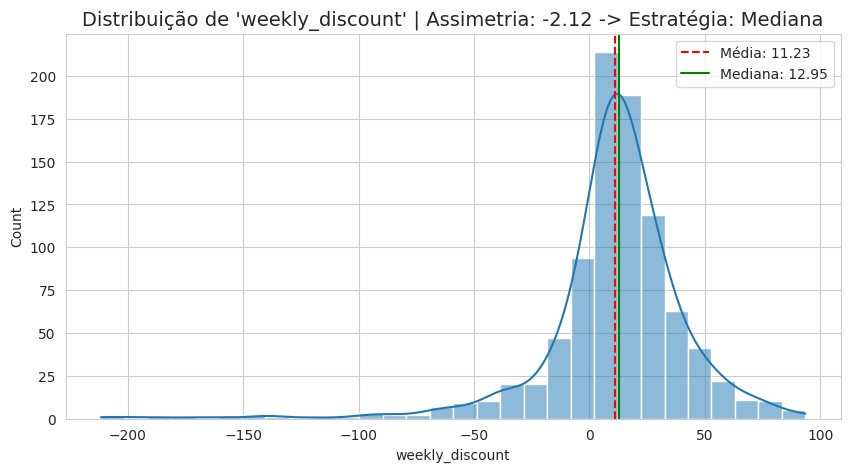

Coluna 'weekly_discount' imputada com a Mediana (12.95).


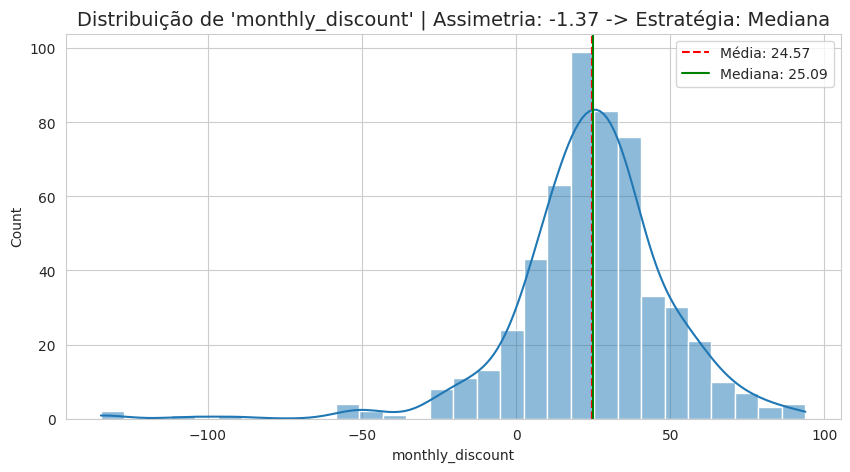

Coluna 'monthly_discount' imputada com a Mediana (25.09).


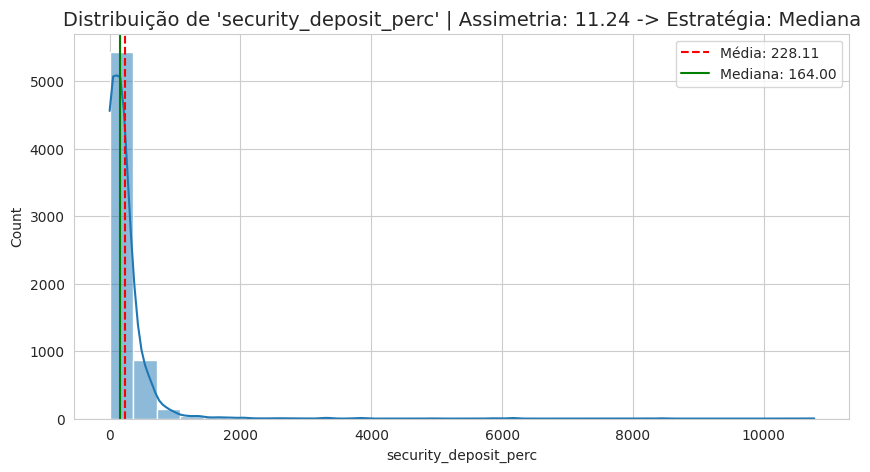

Coluna 'security_deposit_perc' imputada com a Mediana (164.00).


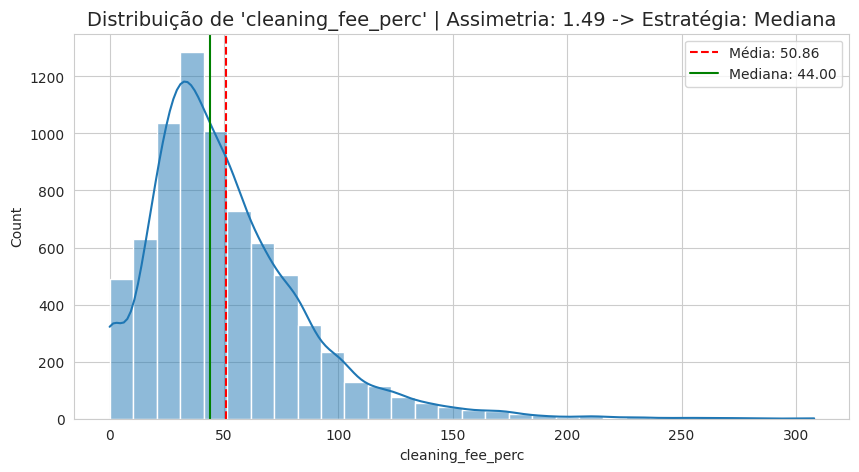

Coluna 'cleaning_fee_perc' imputada com a Mediana (44.00).


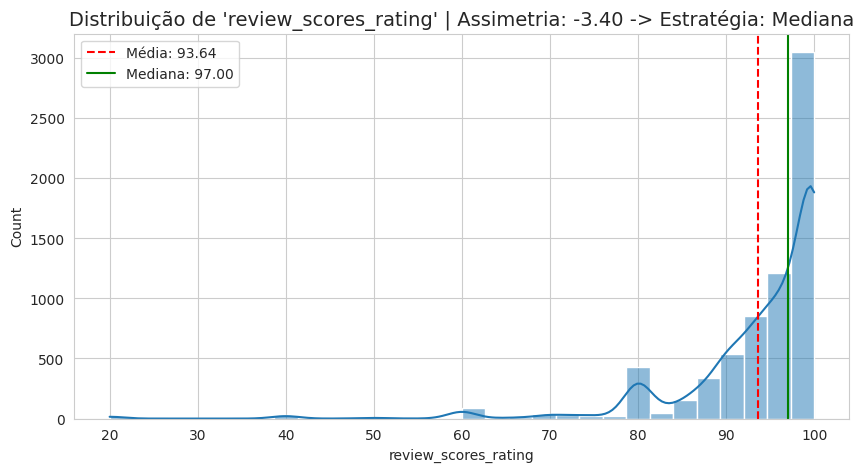

Coluna 'review_scores_rating' imputada com a Mediana (97.00).


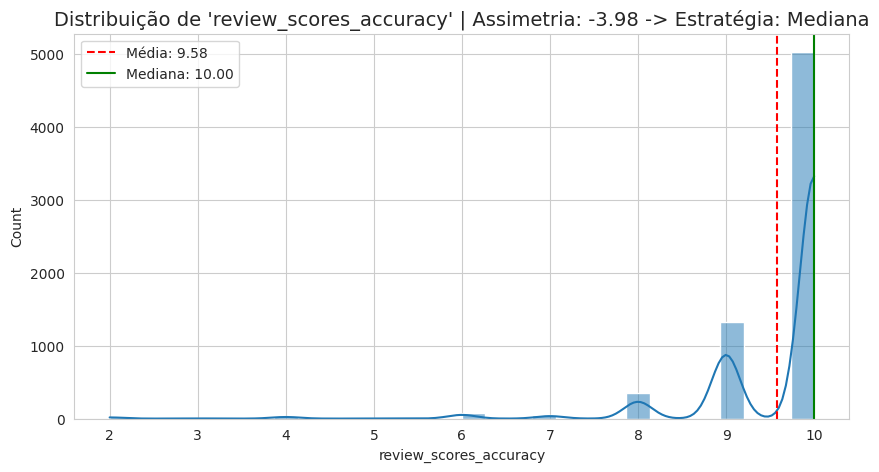

Coluna 'review_scores_accuracy' imputada com a Mediana (10.00).


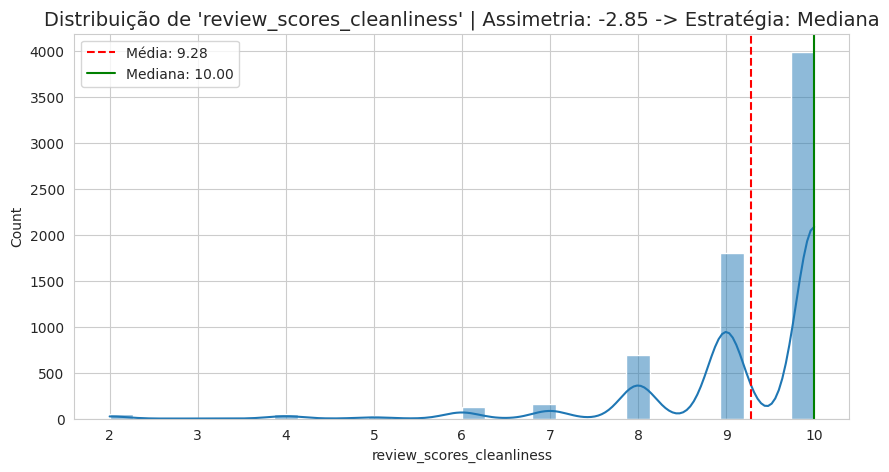

Coluna 'review_scores_cleanliness' imputada com a Mediana (10.00).


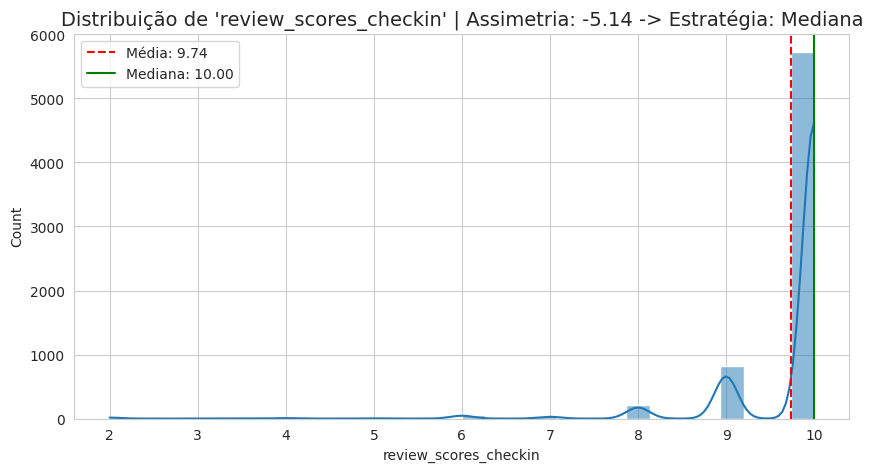

Coluna 'review_scores_checkin' imputada com a Mediana (10.00).


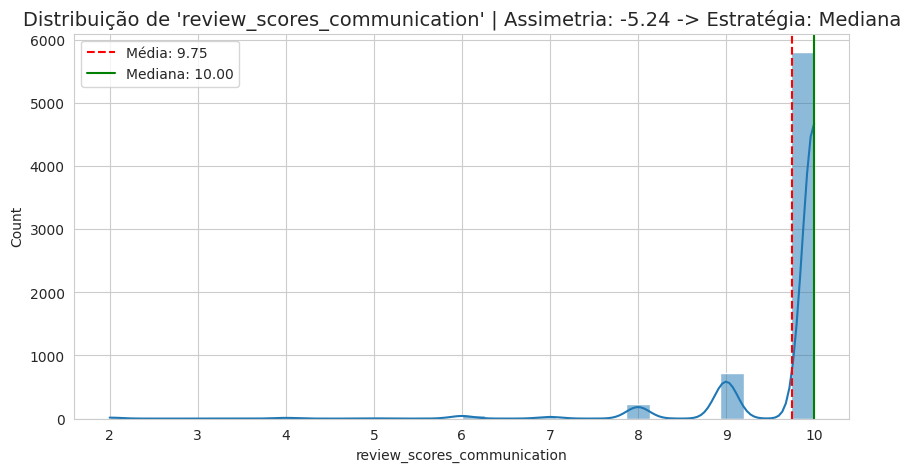

Coluna 'review_scores_communication' imputada com a Mediana (10.00).


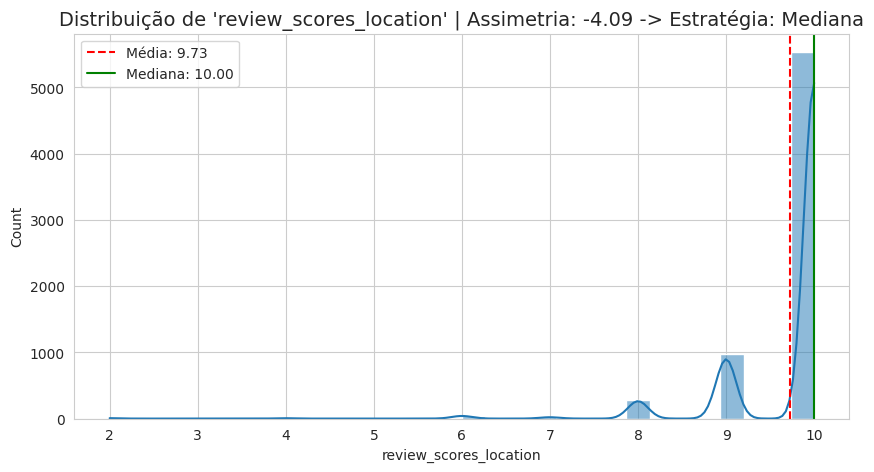

Coluna 'review_scores_location' imputada com a Mediana (10.00).


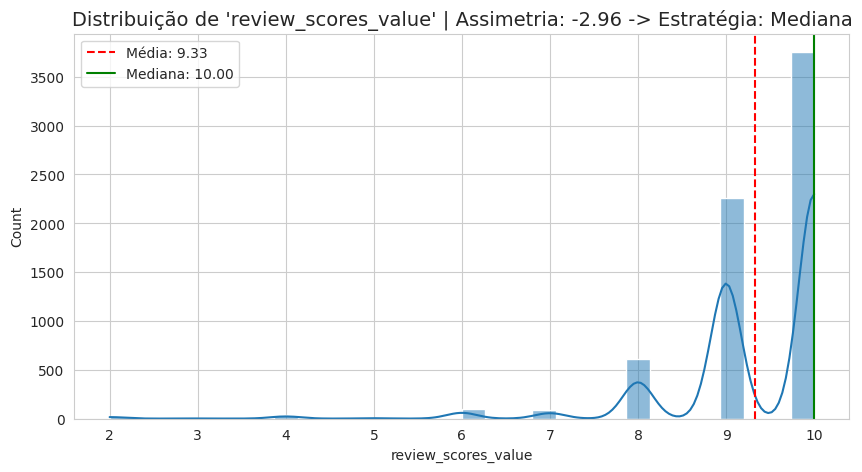

Coluna 'review_scores_value' imputada com a Mediana (10.00).


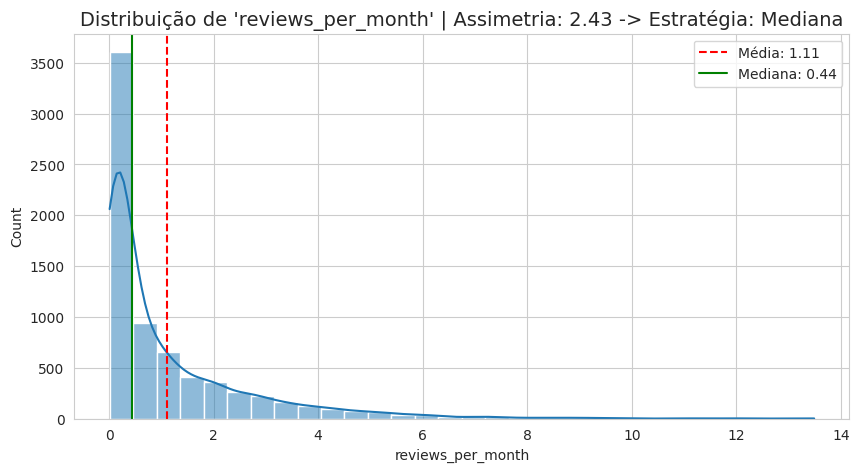

Coluna 'reviews_per_month' imputada com a Mediana (0.44).


In [ ]:
for col in numerical_missing:
    if not df_imputed[col].dropna().empty:
        skewness = df_imputed[col].skew()
        if abs(skewness) > 1.0:
            strategy = 'Mediana'
            value_to_impute = df_imputed[col].median()
        else:
            strategy = 'Média'
            value_to_impute = df_imputed[col].mean()


    plt.figure(figsize=(10, 5))
    sns.histplot(df_imputed[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribuição de '{col}' | Assimetria: {skewness:.2f} -> Estratégia: {strategy}", fontsize=14)

    if not df_imputed[col].dropna().empty:
        plt.axvline(df_imputed[col].mean(), color='red', linestyle='--', label=f'Média: {df_imputed[col].mean():.2f}')
        plt.axvline(df_imputed[col].median(), color='green', linestyle='-', label=f'Mediana: {df_imputed[col].median():.2f}')

        plt.legend()

    plt.show()

    df_imputed[col] = df_imputed[col].fillna(value_to_impute)
    print(f"Coluna '{col}' imputada com a {strategy} ({value_to_impute:.2f}).")

## Análise e Imputação para Dados CATEGÓRICOS Ausentes

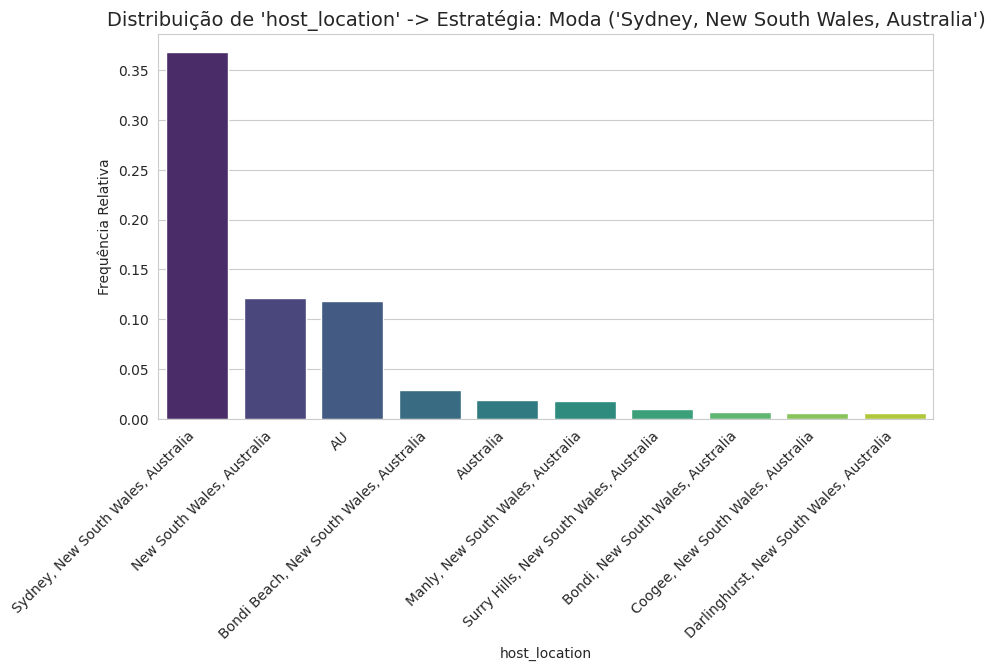

Coluna 'host_location' imputada com a Moda ('Sydney, New South Wales, Australia').
Coluna 'host_about' imputada com a Moda ('My team and I at The Apartment Service are proud to have been helping peopl...').


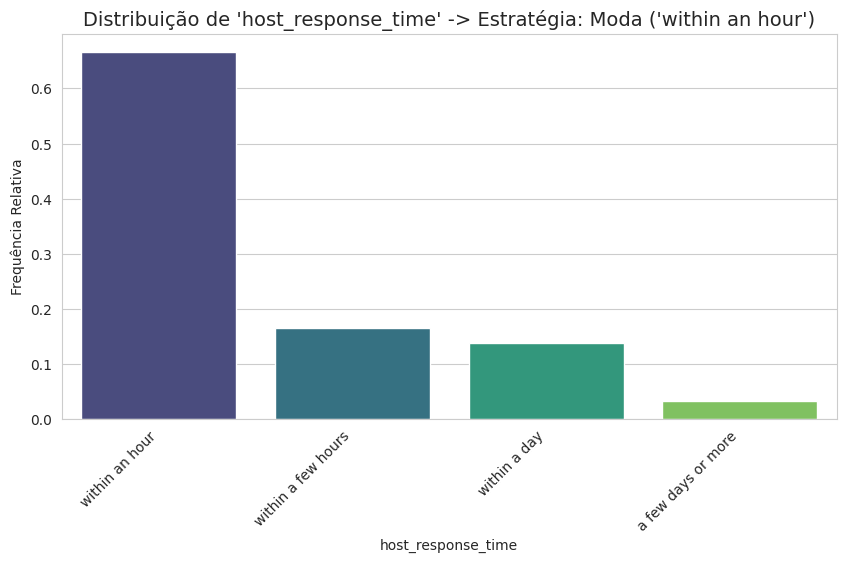

Coluna 'host_response_time' imputada com a Moda ('within an hour').


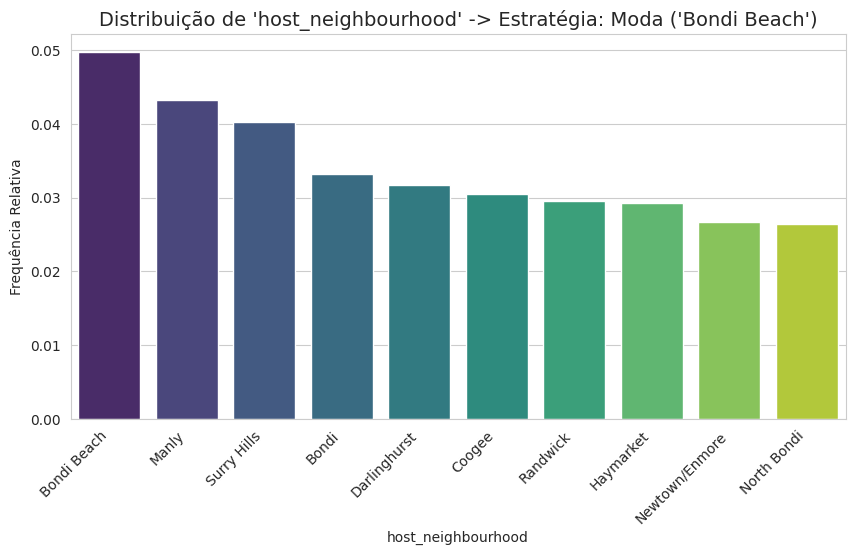

Coluna 'host_neighbourhood' imputada com a Moda ('Bondi Beach').


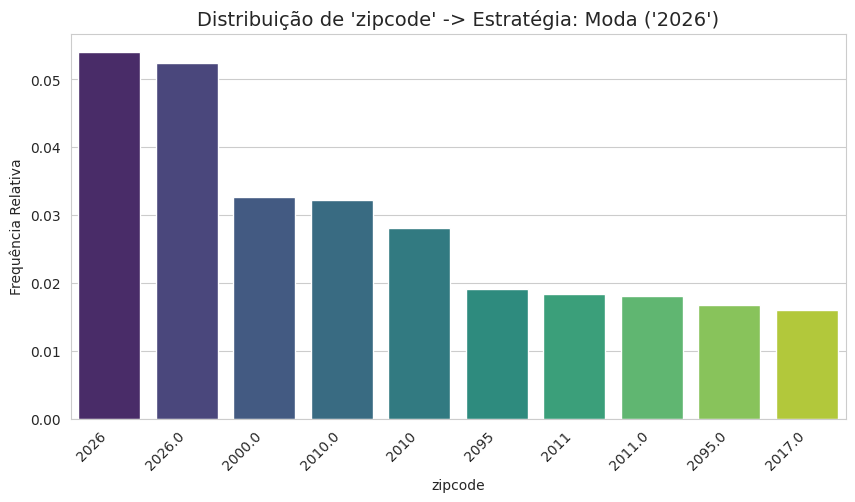

Coluna 'zipcode' imputada com a Moda ('2026').


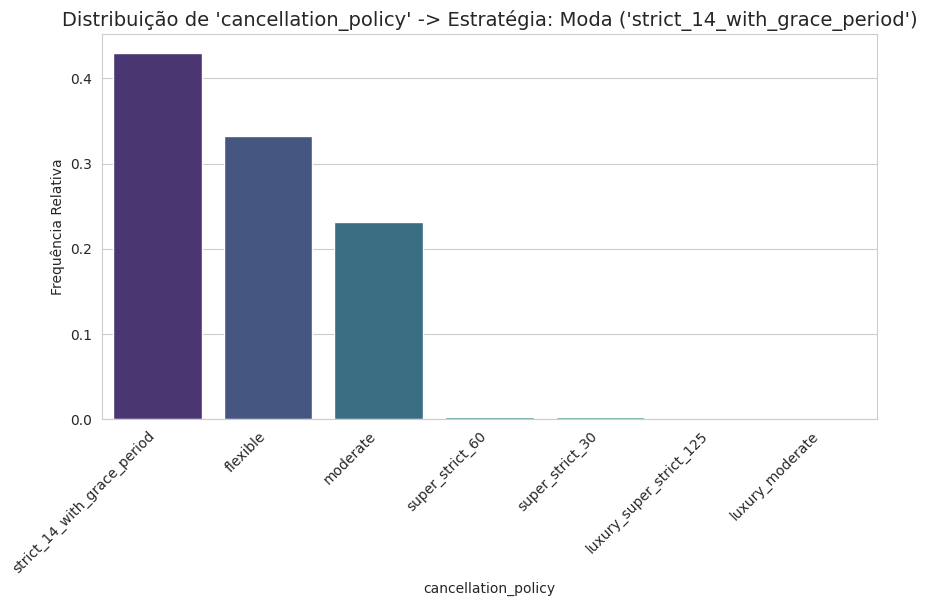

Coluna 'cancellation_policy' imputada com a Moda ('strict_14_with_grace_period').


In [ ]:
high_cardinality_text_cols = ['space', 'notes', 'transit', 'access', 'interaction',
                              'house_rules', 'host_about', 'neighborhood_overview', 'summary']

for col in categorical_missing:

    mode_val = df_imputed[col].mode()[0]


    if col not in high_cardinality_text_cols:
        plt.figure(figsize=(10, 5))
        top_categories = df_imputed[col].value_counts(normalize=True).head(10)
        sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis', hue=top_categories.index, legend=False)
        plt.title(f"Distribuição de '{col}' -> Estratégia: Moda ('{mode_val}')", fontsize=14)
        plt.ylabel('Frequência Relativa')
        plt.xticks(rotation=45, ha='right')
        plt.show()


    df_imputed[col] = df_imputed[col].fillna(mode_val)


    mode_print = (str(mode_val)[:75] + '...') if len(str(mode_val)) > 75 else str(mode_val)
    print(f"Coluna '{col}' imputada com a Moda ('{mode_print}').")

# Análise e Imputação para DATAS faltantes

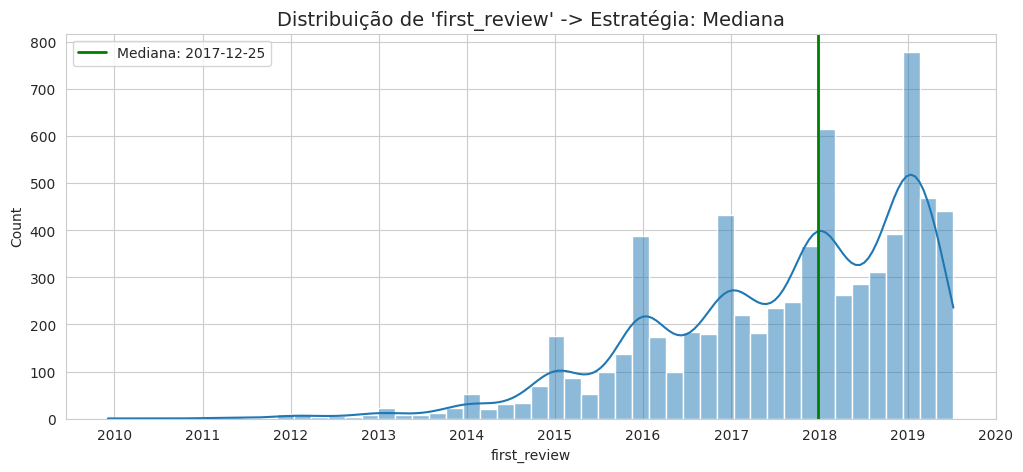

Coluna de data 'first_review' imputada com a Mediana (2017-12-25).


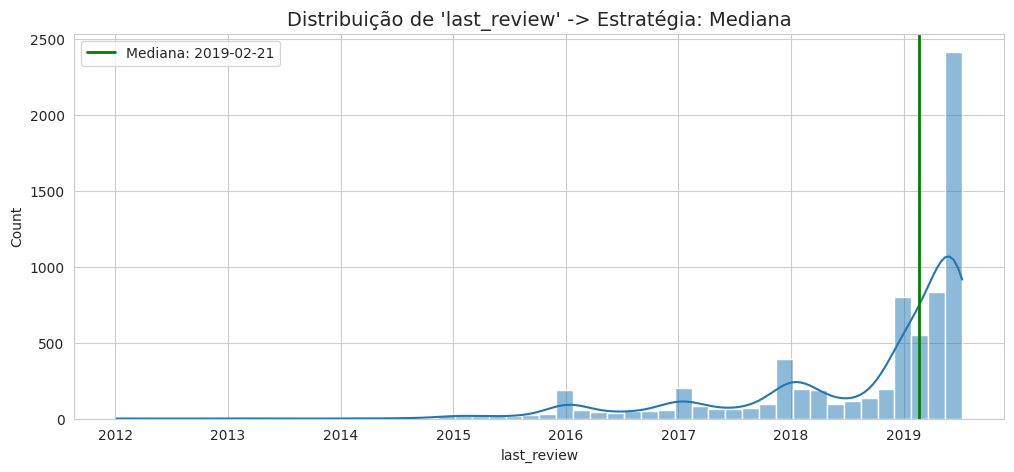

Coluna de data 'last_review' imputada com a Mediana (2019-02-21).


In [ ]:
date_cols_missing = [col for col in df_imputed.columns if df_imputed[col].isnull().sum() > 0 and 'datetime' in str(df_imputed[col].dtype)]

for col in date_cols_missing:
    median_date = df_imputed[col].median()

    plt.figure(figsize=(12, 5))
    sns.histplot(df_imputed[col].dropna(), kde=True, bins=50)
    plt.axvline(median_date, color='green', linestyle='-', linewidth=2, label=f'Mediana: {median_date.strftime("%Y-%m-%d")}')
    plt.title(f"Distribuição de '{col}' -> Estratégia: Mediana", fontsize=14)
    plt.legend()
    plt.show()

    df_imputed[col] = df_imputed[col].fillna(median_date)
    print(f"Coluna de data '{col}' imputada com a Mediana ({median_date.strftime('%Y-%m-%d')}).")

## Verificação final

In [ ]:
remaining_missing = df_imputed.isnull().sum().sum()

if remaining_missing == 0:
    print("Sucesso! O DataFrame foi completamente imputado e está pronto para a próxima etapa.")
else:
    print(f"Atenção! Ainda restam {remaining_missing} valores ausentes.")

Sucesso! O DataFrame foi completamente imputado e está pronto para a próxima etapa.


# Criando novas features

In [ ]:
df_with_features = df_imputed.copy()
y_series = df_with_features['price']

if 'amenities' in df_with_features.columns:
    df_with_features['amenities_count'] = df_with_features['amenities'].str.count(',') + 1
    df_with_features.loc[df_with_features['amenities'] == '{}', 'amenities_count'] = 0
    luxury_terms = 'Jacuzzi|Pool|Sauna|Gym|Breakfast|Hot Tub|Fireplace|Waterfront'
    df_with_features['has_luxury_amenity'] = df_with_features['amenities'].str.contains(luxury_terms, case=False, na=False).astype(int)

if 'neighbourhood_cleansed' in df_with_features.columns:
    target_means = y_series.groupby(df_with_features['neighbourhood_cleansed']).mean()
    df_with_features['target_encoded_location'] = df_with_features['neighbourhood_cleansed'].map(target_means)

if all(c in df_with_features.columns for c in ['room_type', 'target_encoded_location']):
    mean_target_location = df_with_features['target_encoded_location'].mean()
    df_with_features['location_x_roomtype'] = ((df_with_features['room_type'] == 'Entire home/apt') & (df_with_features['target_encoded_location'] > mean_target_location)).astype(int)

## Tratando outliers (IQR)

In [ ]:
df_final = df_with_features.copy()

numerical_cols_to_treat = df_final.select_dtypes(include=np.number).columns.tolist()
if 'price' in numerical_cols_to_treat:
     numerical_cols_to_treat.remove('price')

for col in numerical_cols_to_treat:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = ((df_final[col] < lower_bound) | (df_final[col] > upper_bound)).sum()
    if outliers_before > 0:
        df_final[col] = np.clip(df_final[col], lower_bound, upper_bound)
        print(f"Coluna '{col}': {outliers_before} outliers tratados.")

print("\nTratamento de outliers concluído.")
print(f"Dataset final pronto para divisão em folds com {df_final.shape[0]} linhas e {df_final.shape[1]} colunas.")

Coluna 'host_id': 99 outliers tratados.
Coluna 'host_response_rate': 1163 outliers tratados.
Coluna 'host_listings_count': 1433 outliers tratados.
Coluna 'host_total_listings_count': 1433 outliers tratados.
Coluna 'latitude': 732 outliers tratados.
Coluna 'longitude': 479 outliers tratados.
Coluna 'accommodates': 740 outliers tratados.
Coluna 'bathrooms': 124 outliers tratados.
Coluna 'bedrooms': 747 outliers tratados.
Coluna 'beds': 188 outliers tratados.
Coluna 'square_feet': 21 outliers tratados.
Coluna 'weekly_discount': 898 outliers tratados.
Coluna 'monthly_discount': 535 outliers tratados.
Coluna 'security_deposit_perc': 1139 outliers tratados.
Coluna 'cleaning_fee_perc': 702 outliers tratados.
Coluna 'guests_included': 1130 outliers tratados.
Coluna 'extra_people_perc': 828 outliers tratados.
Coluna 'minimum_nights': 589 outliers tratados.
Coluna 'maximum_nights': 2 outliers tratados.
Coluna 'minimum_minimum_nights': 520 outliers tratados.
Coluna 'maximum_minimum_nights': 904 o

# Conversão de texto para número (Label Encoding)

In [ ]:
categorical_cols = df_final.select_dtypes(exclude=np.number).columns

le = LabelEncoder()

for col in categorical_cols:
    df_final[col] = le.fit_transform(df_final[col])

print("\nCodificação finalizada com sucesso!")
print(f"O número de colunas foi mantido em: {df_final.shape[1]}")


Codificação finalizada com sucesso!
O número de colunas foi mantido em: 68


# Análise de Multicolinearidade

In [ ]:
correlation_threshold = 0.90
vif_threshold = 10.0
df_temp = df_final.copy()

numeric_cols = df_temp.select_dtypes(include=np.number).columns.tolist()
if 'price' in numeric_cols: numeric_cols.remove('price')
df_numeric = df_temp[numeric_cols]

corr_matrix = df_numeric.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = set([column for column in upper_tri.columns if any(upper_tri[column] > correlation_threshold)])

df_after_corr = df_temp.drop(columns=list(to_drop_corr), errors='ignore')

X_vif = df_after_corr.select_dtypes(include=np.number).copy()
if 'price' in X_vif.columns: X_vif = X_vif.drop('price', axis=1)
X_vif.dropna(inplace=True)

cols_to_keep = X_vif.columns.tolist()
dropped_cols_vif = []

while len(cols_to_keep) > 1:
    X_vif_const = add_constant(X_vif[cols_to_keep])
    vifs = []
    for i in range(len(cols_to_keep)):
        try: vif_value = variance_inflation_factor(X_vif_const.values, i + 1)
        except Exception: vif_value = np.inf
        vifs.append(np.inf if vif_value > 1e9 else vif_value)

    max_vif_idx = np.argmax(vifs)
    if vifs[max_vif_idx] >= vif_threshold or np.isinf(vifs[max_vif_idx]):
        dropped_cols_vif.append(cols_to_keep.pop(max_vif_idx))
    else: break

all_dropped_cols = list(to_drop_corr) + dropped_cols_vif
df_encoded = df_final.drop(columns=all_dropped_cols, errors='ignore')

print(f"Colunas removidas por correlação (> {correlation_threshold}): {list(to_drop_corr)}")
print(f"Colunas removidas por VIF (>= {vif_threshold}): {dropped_cols_vif}")
print(f"Dataset final para Label Encoding tem {df_encoded.shape[1]} colunas.")

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Colunas removidas por correlação (> 0.9): ['minimum_minimum_nights', 'maximum_minimum_nights', 'host_since', 'availability_60', 'maximum_maximum_nights', 'calculated_host_listings_count', 'minimum_maximum_nights', 'host_total_listings_count', 'maximum_nights_avg_ntm', 'minimum_nights_avg_ntm', 'availability_90']
Colunas removidas por VIF (>= 10.0): []
Dataset final para Label Encoding tem 57 colunas.


## Divisão K Fold (5 Folds)

In [ ]:
Y_col = 'price'
X = df_encoded.drop(Y_col, axis=1)
y = df_encoded[Y_col]

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

output_dir = 'folds'
os.makedirs(output_dir, exist_ok=True)

for i, (train_index, test_index) in enumerate(kfold.split(X, y)):
    fold_num = i + 1

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)

    train_filename = os.path.join(output_dir, f'train_{fold_num}.csv')
    test_filename = os.path.join(output_dir, f'test_{fold_num}.csv')

    train_df.to_csv(train_filename, index=False)
    test_df.to_csv(test_filename, index=False)

    print(f"Fold {fold_num}: {train_filename} e {test_filename} salvos com sucesso.")

print("\nDivisão concluída!")

Fold 1: folds/train_1.csv e folds/test_1.csv salvos com sucesso.
Fold 2: folds/train_2.csv e folds/test_2.csv salvos com sucesso.
Fold 3: folds/train_3.csv e folds/test_3.csv salvos com sucesso.
Fold 4: folds/train_4.csv e folds/test_4.csv salvos com sucesso.
Fold 5: folds/train_5.csv e folds/test_5.csv salvos com sucesso.

Divisão concluída!


# Grid Search para o LightGBM

In [ ]:
Y_col = 'price'


train_dfs = [pd.read_csv(f'folds/train_{i+1}.csv') for i in range(N_FOLDS)]

full_train_df = pd.concat(train_dfs, ignore_index=True)
X_full_train = full_train_df.drop(Y_col, axis=1)
y_full_train = full_train_df[Y_col]



param_grid_lgbm = {
    'n_estimators': [25, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [10, 20, 31],
    'max_depth': [5, 10, None],
}

lgbm = LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

grid_search_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_lgbm,
    scoring='r2',
    cv=N_FOLDS,
    verbose=0,
    n_jobs=-1
)

start_time_lgbm = time.time()

grid_search_lgbm.fit(X_full_train, y_full_train)

time_lgbm = time.time() - start_time_lgbm

best_r2_cv = grid_search_lgbm.best_score_
best_params = grid_search_lgbm.best_params_

best_idx = grid_search_lgbm.best_index_

cv_results = grid_search_lgbm.cv_results_
fold_scores = [cv_results[f'split{i}_test_score'][best_idx] for i in range(N_FOLDS)]

mean_r2 = np.mean(fold_scores)
std_r2 = np.std(fold_scores)

print("\n--- RESULTADOS DETALHADOS DO GRID SEARCH (LIGHTGBM) ---")
print(f"Tempo de Execução Total: {time_lgbm/60:.2f} minutos")
print(f"Melhores Parâmetros Encontrados: {best_params}")
print("\n--- R² DE CADA FOLD (Validação Cruzada) ---")

for i, r2 in enumerate(fold_scores):
    print(f"R² Fold {i+1}: {r2:.4f}")

print("\n--- RESUMO ESTATÍSTICO ---")
print(f"R² Médio (CV): {mean_r2:.4f}")
print(f"Desvio Padrão (DP): {std_r2:.4f}")


--- RESULTADOS DETALHADOS DO GRID SEARCH (LIGHTGBM) ---
Tempo de Execução Total: 10.04 minutos
Melhores Parâmetros Encontrados: {'learning_rate': 0.1, 'max_depth': None, 'n_estimators': 100, 'num_leaves': 31}

--- R² DE CADA FOLD (Validação Cruzada) ---
R² Fold 1: 0.9323
R² Fold 2: 0.9348
R² Fold 3: 0.9304
R² Fold 4: 0.9359
R² Fold 5: 0.9345

--- RESUMO ESTATÍSTICO ---
R² Médio (CV): 0.9336
Desvio Padrão (DP): 0.0020


# Treino e Teste com os 5 folds (LightGBM)

In [ ]:
all_y_test_lgbm = []
all_predictions_lgbm = []
maes_lgbm = []; mses_lgbm = []; rmses_lgbm = []; r2s_lgbm = []
train_times_lgbm = []; test_times_lgbm = []; model_sizes_lgbm = []
Y_col = 'price'

for i in range(N_FOLDS):
    fold_num = i + 1
    print(f"\n--- Processando Fold {fold_num} ---")
    train_df = pd.read_csv(f'folds/train_{fold_num}.csv')
    test_df = pd.read_csv(f'folds/test_{fold_num}.csv')
    X_train = train_df.drop(Y_col, axis=1); y_train = train_df[Y_col]
    X_test = test_df.drop(Y_col, axis=1); y_test = test_df[Y_col]

    model_lgbm = LGBMRegressor(learning_rate=0.1, max_depth=None, n_estimators=100, num_leaves=31, random_state=RANDOM_STATE, n_jobs=1, verbose=-1)

    start_train_time = time.time(); model_lgbm.fit(X_train, y_train); train_time = time.time() - start_train_time
    train_times_lgbm.append(train_time)
    start_test_time = time.time(); predictions = model_lgbm.predict(X_test); test_time = time.time() - start_test_time
    test_times_lgbm.append(test_time)
    all_y_test_lgbm.extend(y_test); all_predictions_lgbm.extend(predictions)
    mae = mean_absolute_error(y_test, predictions); mse = mean_squared_error(y_test, predictions); rmse = np.sqrt(mse); r2 = r2_score(y_test, predictions)
    maes_lgbm.append(mae); mses_lgbm.append(mse); rmses_lgbm.append(rmse); r2s_lgbm.append(r2)

    temp_model_path = f'temp_lgbm_model_fold_{fold_num}.joblib'; joblib.dump(model_lgbm, temp_model_path); model_size_mb = os.path.getsize(temp_model_path) / (1024 * 1024); model_sizes_lgbm.append(model_size_mb); os.remove(temp_model_path)
    print(f"MAE: {mae:.4f}"); print(f"MSE: {mse:.4f}"); print(f"RMSE: {rmse:.4f}"); print(f"R²: {r2:.4f}")
    print(f"Tempo de Treino: {train_time:.4f} segundos"); print(f"Tempo de Teste: {test_time:.4f} segundos"); print(f"Tamanho do Modelo: {model_size_mb:.4f} MB")

all_y_test_lgbm = np.array(all_y_test_lgbm); all_predictions_lgbm = np.array(all_predictions_lgbm)

print("\n--- MÉDIA DOS RESULTADOS (LightGBM) ---")
print(f"MAE Médio: {np.mean(maes_lgbm):.4f} ± {np.std(maes_lgbm):.4f}")
print(f"MSE Médio: {np.mean(mses_lgbm):.4f} ± {np.std(mses_lgbm):.4f}")
print(f"RMSE Médio: {np.mean(rmses_lgbm):.4f} ± {np.std(rmses_lgbm):.4f}")
print(f"R² Médio: {np.mean(r2s_lgbm):.4f} ± {np.std(r2s_lgbm):.4f}")
print(f"Tempo Médio de Treino: {np.mean(train_times_lgbm):.4f} ± {np.std(train_times_lgbm):.4f} segundos")
print(f"Tempo Médio de Teste: {np.mean(test_times_lgbm):.4f} ± {np.std(test_times_lgbm):.4f} segundos")
print(f"Tamanho Médio do Modelo: {np.mean(model_sizes_lgbm):.4f} ± {np.std(model_sizes_lgbm):.4f} MB")


--- Processando Fold 1 ---
MAE: 61.2836
MSE: 20249.4680
RMSE: 142.3006
R²: 0.6896
Tempo de Treino: 0.3673 segundos
Tempo de Teste: 0.0215 segundos
Tamanho do Modelo: 0.2635 MB

--- Processando Fold 2 ---
MAE: 61.1482
MSE: 14654.3856
RMSE: 121.0553
R²: 0.7646
Tempo de Treino: 0.3619 segundos
Tempo de Teste: 0.0213 segundos
Tamanho do Modelo: 0.2638 MB

--- Processando Fold 3 ---
MAE: 61.4040
MSE: 15660.2648
RMSE: 125.1410
R²: 0.7689
Tempo de Treino: 0.7894 segundos
Tempo de Teste: 0.0275 segundos
Tamanho do Modelo: 0.2637 MB

--- Processando Fold 4 ---
MAE: 62.0526
MSE: 16398.8496
RMSE: 128.0580
R²: 0.7441
Tempo de Treino: 0.3654 segundos
Tempo de Teste: 0.0253 segundos
Tamanho do Modelo: 0.2634 MB

--- Processando Fold 5 ---
MAE: 61.9756
MSE: 15723.6590
RMSE: 125.3940
R²: 0.7133
Tempo de Treino: 0.3488 segundos
Tempo de Teste: 0.0297 segundos
Tamanho do Modelo: 0.2634 MB

--- MÉDIA DOS RESULTADOS (LightGBM) ---
MAE Médio: 61.5728 ± 0.3701
MSE Médio: 16537.3254 ± 1937.8302
RMSE Médio: 

# Grid Search para o Random Forest

In [ ]:
Y_col = 'price'

train_dfs = [pd.read_csv(f'folds/train_{i+1}.csv') for i in range(N_FOLDS)]

full_train_df = pd.concat(train_dfs, ignore_index=True)
X_full_train = full_train_df.drop(Y_col, axis=1)
y_full_train = full_train_df[Y_col]

param_grid_rf = {

    'max_depth': [5, 10,  None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 3, 5],
    'n_estimators': [25, 50, 100]
}


rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='r2',
    cv=5,
    verbose=2,
    n_jobs=-1
)

start_time_rf = time.time()

grid_search.fit(X_full_train, y_full_train)

time_rf = time.time() - start_time_rf


best_r2_cv = grid_search.best_score_
best_params = grid_search.best_params_
best_model_rf = grid_search.best_estimator_
best_idx = grid_search.best_index_

cv_results = grid_search.cv_results_
fold_scores = [cv_results[f'split{i}_test_score'][best_idx] for i in range(N_FOLDS)]

mean_r2 = np.mean(fold_scores)
std_r2 = np.std(fold_scores)

print("\n--- RESULTADOS DETALHADOS DO GRID SEARCH (MELHOR ESTIMADOR) ---")
print(f"Tempo de Execução Total: {time_rf/60:.2f} minutos")
print(f"Melhores Parâmetros Encontrados: {best_params}")
print("\n--- R² DE CADA FOLD (Validação Cruzada) ---")

for i, r2 in enumerate(fold_scores):
    print(f"R² Fold {i+1}: {r2:.4f}")

print("\n--- RESUMO ESTATÍSTICO ---")
print(f"R² Médio (CV): {mean_r2:.4f}")
print(f"Desvio Padrão (DP): {std_r2:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits

--- RESULTADOS DETALHADOS DO GRID SEARCH (MELHOR ESTIMADOR) ---
Tempo de Execução Total: 143.52 minutos
Melhores Parâmetros Encontrados: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

--- R² DE CADA FOLD (Validação Cruzada) ---
R² Fold 1: 0.9990
R² Fold 2: 0.9989
R² Fold 3: 0.9990
R² Fold 4: 0.9990
R² Fold 5: 0.9990

--- RESUMO ESTATÍSTICO ---
R² Médio (CV): 0.9990
Desvio Padrão (DP): 0.0001


# Treino e Teste com os 5 folds (Random Forest)

In [ ]:
all_y_test_rf = []
all_predictions_rf = []
maes_rf = []
mses_rf = []
rmses_rf = []
r2s_rf = []
train_times_rf = []
test_times_rf = []
model_sizes_rf = []
Y_col = 'price'

for i in range(N_FOLDS):
    fold_num = i + 1
    print(f"\n--- Processando Fold {fold_num} ---")
    train_df = pd.read_csv(f'folds/train_{fold_num}.csv')
    test_df = pd.read_csv(f'folds/test_{fold_num}.csv')
    X_train = train_df.drop(Y_col, axis=1); y_train = train_df[Y_col]
    X_test = test_df.drop(Y_col, axis=1); y_test = test_df[Y_col]

    model_rf = RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=RANDOM_STATE, n_jobs=-1)

    start_train_time = time.time(); model_rf.fit(X_train, y_train); train_time = time.time() - start_train_time
    train_times_rf.append(train_time)
    start_test_time = time.time(); predictions = model_rf.predict(X_test); test_time = time.time() - start_test_time
    test_times_rf.append(test_time)
    all_y_test_rf.extend(y_test); all_predictions_rf.extend(predictions)
    mae = mean_absolute_error(y_test, predictions); mse = mean_squared_error(y_test, predictions); rmse = np.sqrt(mse); r2 = r2_score(y_test, predictions)
    maes_rf.append(mae); mses_rf.append(mse); rmses_rf.append(rmse); r2s_rf.append(r2)

    temp_model_path = f'temp_rf_model_fold_{fold_num}.joblib'; joblib.dump(model_rf, temp_model_path); model_size_mb = os.path.getsize(temp_model_path) / (1024 * 1024); model_sizes_rf.append(model_size_mb); os.remove(temp_model_path)
    print(f"MAE: {mae:.4f}"); print(f"MSE: {mse:.4f}"); print(f"RMSE: {rmse:.4f}"); print(f"R²: {r2:.4f}")
    print(f"Tempo de Treino: {train_time:.4f} segundos"); print(f"Tempo de Teste: {test_time:.4f} segundos"); print(f"Tamanho do Modelo: {model_size_mb:.4f} MB")

all_y_test_rf = np.array(all_y_test_rf); all_predictions_rf = np.array(all_predictions_rf)

print("\n--- MÉDIA DOS RESULTADOS (Random Forest) ---")
print(f"MAE Médio: {np.mean(maes_rf):.4f} ± {np.std(maes_rf):.4f}")
print(f"MSE Médio: {np.mean(mses_rf):.4f} ± {np.std(mses_rf):.4f}")
print(f"RMSE Médio: {np.mean(rmses_rf):.4f} ± {np.std(rmses_rf):.4f}")
print(f"R² Médio: {np.mean(r2s_rf):.4f} ± {np.std(r2s_rf):.4f}")
print(f"Tempo Médio de Treino: {np.mean(train_times_rf):.4f} ± {np.std(train_times_rf):.4f} segundos")
print(f"Tempo Médio de Teste: {np.mean(test_times_rf):.4f} ± {np.std(test_times_rf):.4f} segundos")
print(f"Tamanho Médio do Modelo: {np.mean(model_sizes_rf):.4f} ± {np.std(model_sizes_rf):.4f} MB")


--- Processando Fold 1 ---
MAE: 67.2284
MSE: 22642.0491
RMSE: 150.4728
R²: 0.6529
Tempo de Treino: 20.9420 segundos
Tempo de Teste: 0.0709 segundos
Tamanho do Modelo: 57.3079 MB

--- Processando Fold 2 ---
MAE: 66.3108
MSE: 16326.9877
RMSE: 127.7771
R²: 0.7377
Tempo de Treino: 18.5911 segundos
Tempo de Teste: 0.1225 segundos
Tamanho do Modelo: 57.3276 MB

--- Processando Fold 3 ---
MAE: 65.2805
MSE: 18789.9068
RMSE: 137.0763
R²: 0.7227
Tempo de Treino: 17.9367 segundos
Tempo de Teste: 0.0687 segundos
Tamanho do Modelo: 57.3133 MB

--- Processando Fold 4 ---
MAE: 66.5160
MSE: 17570.9873
RMSE: 132.5556
R²: 0.7259
Tempo de Treino: 16.7599 segundos
Tempo de Teste: 0.0699 segundos
Tamanho do Modelo: 57.1740 MB

--- Processando Fold 5 ---
MAE: 68.6781
MSE: 20898.8889
RMSE: 144.5645
R²: 0.6189
Tempo de Treino: 18.2074 segundos
Tempo de Teste: 0.1203 segundos
Tamanho do Modelo: 57.4282 MB

--- MÉDIA DOS RESULTADOS (Random Forest) ---
MAE Médio: 66.8027 ± 1.1260
MSE Médio: 19245.7640 ± 2271.54

# Grid Search para o XGBoost

In [ ]:
Y_col = 'price'

train_dfs = [pd.read_csv(f'folds/train_{i+1}.csv') for i in range(N_FOLDS)]

full_train_df = pd.concat(train_dfs, ignore_index=True)
X_full_train = full_train_df.drop(Y_col, axis=1)
y_full_train = full_train_df[Y_col]


param_grid_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 10, None],
    'n_estimators': [25, 50, 100],
    'subsample': [0.7, 0.85, 1.0],
}


xgb = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist')

grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring='r2',
    cv=N_FOLDS,
    verbose=0,
    n_jobs=-1
)

start_time_xgb = time.time()

grid_search_xgb.fit(X_full_train, y_full_train)

time_xgb = time.time() - start_time_xgb


best_r2_cv = grid_search_xgb.best_score_
best_params = grid_search_xgb.best_params_
best_idx = grid_search_xgb.best_index_

cv_results = grid_search_xgb.cv_results_
fold_scores = [cv_results[f'split{i}_test_score'][best_idx] for i in range(N_FOLDS)]

mean_r2 = np.mean(fold_scores)
std_r2 = np.std(fold_scores)

print("\n--- RESULTADOS DETALHADOS DO GRID SEARCH (XGBOOST) ---")
print(f"Tempo de Execução Total: {time_xgb/60:.2f} minutos")
print(f"Melhores Parâmetros Encontrados: {best_params}")
print("\n--- R² DE CADA FOLD (Validação Cruzada) ---")

for i, r2 in enumerate(fold_scores):
    print(f"R² Fold {i+1}: {r2:.4f}")

print("\n--- RESUMO ESTATÍSTICO ---")
print(f"R² Médio (CV): {mean_r2:.4f}")
print(f"Desvio Padrão (DP): {std_r2:.4f}")


--- RESULTADOS DETALHADOS DO GRID SEARCH (XGBOOST) ---
Tempo de Execução Total: 11.32 minutos
Melhores Parâmetros Encontrados: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'subsample': 0.85}

--- R² DE CADA FOLD (Validação Cruzada) ---
R² Fold 1: 0.9954
R² Fold 2: 0.9954
R² Fold 3: 0.9955
R² Fold 4: 0.9952
R² Fold 5: 0.9957

--- RESUMO ESTATÍSTICO ---
R² Médio (CV): 0.9954
Desvio Padrão (DP): 0.0001


# Treino e Teste com os 5 folds (XGBoost)

In [ ]:
all_y_test_xgb = []
all_predictions_xgb = []
maes_xgb = []; mses_xgb = []; rmses_xgb = []; r2s_xgb = []
train_times_xgb = []; test_times_xgb = []; model_sizes_xgb = []
Y_col = 'price'

for i in range(N_FOLDS):
    fold_num = i + 1
    print(f"\n--- Processando Fold {fold_num} ---")
    train_df = pd.read_csv(f'folds/train_{fold_num}.csv')
    test_df = pd.read_csv(f'folds/test_{fold_num}.csv')
    X_train = train_df.drop(Y_col, axis=1); y_train = train_df[Y_col]
    X_test = test_df.drop(Y_col, axis=1); y_test = test_df[Y_col]

    model_xgb = XGBRegressor(learning_rate=0.1, max_depth=10, n_estimators=100, subsample=0.85, random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist')

    start_train_time = time.time(); model_xgb.fit(X_train, y_train); train_time = time.time() - start_train_time
    train_times_xgb.append(train_time)
    start_test_time = time.time(); predictions = model_xgb.predict(X_test); test_time = time.time() - start_test_time
    test_times_xgb.append(test_time)
    all_y_test_xgb.extend(y_test); all_predictions_xgb.extend(predictions)
    mae = mean_absolute_error(y_test, predictions); mse = mean_squared_error(y_test, predictions); rmse = np.sqrt(mse); r2 = r2_score(y_test, predictions)
    maes_xgb.append(mae); mses_xgb.append(mse); rmses_xgb.append(rmse); r2s_xgb.append(r2)

    temp_model_path = f'temp_xgb_model_fold_{fold_num}.joblib'; joblib.dump(model_xgb, temp_model_path); model_size_mb = os.path.getsize(temp_model_path) / (1024 * 1024); model_sizes_xgb.append(model_size_mb); os.remove(temp_model_path)
    print(f"MAE: {mae:.4f}"); print(f"MSE: {mse:.4f}"); print(f"RMSE: {rmse:.4f}"); print(f"R²: {r2:.4f}")
    print(f"Tempo de Treino: {train_time:.4f} segundos"); print(f"Tempo de Teste: {test_time:.4f} segundos"); print(f"Tamanho do Modelo: {model_size_mb:.4f} MB")

all_y_test_xgb = np.array(all_y_test_xgb); all_predictions_xgb = np.array(all_predictions_xgb)

print("\n--- MÉDIA DOS RESULTADOS (XGBoost) ---")
print(f"MAE Médio: {np.mean(maes_xgb):.4f} ± {np.std(maes_xgb):.4f}")
print(f"MSE Médio: {np.mean(mses_xgb):.4f} ± {np.std(mses_xgb):.4f}")
print(f"RMSE Médio: {np.mean(rmses_xgb):.4f} ± {np.std(rmses_xgb):.4f}")
print(f"R² Médio: {np.mean(r2s_xgb):.4f} ± {np.std(r2s_xgb):.4f}")
print(f"Tempo Médio de Treino: {np.mean(train_times_xgb):.4f} ± {np.std(train_times_xgb):.4f} segundos")
print(f"Tempo Médio de Teste: {np.mean(test_times_xgb):.4f} ± {np.std(test_times_xgb):.4f} segundos")
print(f"Tamanho Médio do Modelo: {np.mean(model_sizes_xgb):.4f} ± {np.std(model_sizes_xgb):.4f} MB")


--- Processando Fold 1 ---
MAE: 63.3695
MSE: 21748.7933
RMSE: 147.4747
R²: 0.6666
Tempo de Treino: 3.2100 segundos
Tempo de Teste: 0.0186 segundos
Tamanho do Modelo: 2.1272 MB

--- Processando Fold 2 ---
MAE: 64.3674
MSE: 17411.4601
RMSE: 131.9525
R²: 0.7203
Tempo de Treino: 3.1666 segundos
Tempo de Teste: 0.0194 segundos
Tamanho do Modelo: 2.1238 MB

--- Processando Fold 3 ---
MAE: 61.2068
MSE: 17163.8132
RMSE: 131.0107
R²: 0.7467
Tempo de Treino: 3.0408 segundos
Tempo de Teste: 0.0184 segundos
Tamanho do Modelo: 2.0359 MB

--- Processando Fold 4 ---
MAE: 61.5136
MSE: 16642.5643
RMSE: 129.0061
R²: 0.7403
Tempo de Treino: 5.0538 segundos
Tempo de Teste: 0.0190 segundos
Tamanho do Modelo: 2.1615 MB

--- Processando Fold 5 ---
MAE: 64.9123
MSE: 19500.0426
RMSE: 139.6426
R²: 0.6444
Tempo de Treino: 3.2022 segundos
Tempo de Teste: 0.0189 segundos
Tamanho do Modelo: 2.1291 MB

--- MÉDIA DOS RESULTADOS (XGBoost) ---
MAE Médio: 63.0739 ± 1.4873
MSE Médio: 18493.3347 ± 1896.0434
RMSE Médio: 1

# Teste Estatístico de Friedman-Nemenyi

MAE
• Friedman p = 0.022371 → significativo
• Avg ranks: Random Forest: 3.00, XGBoost: 1.60, LightGBM: 1.40 



/usr/local/lib/python3.12/dist-packages/scikit_posthocs/_plotting.py:528: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (x for x in crossbar_sets if len(x) > 1), key=lambda x: ranks[list(x)].min()
/usr/local/lib/python3.12/dist-packages/scikit_posthocs/_plotting.py:549: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [ranks[i] for i in bar],


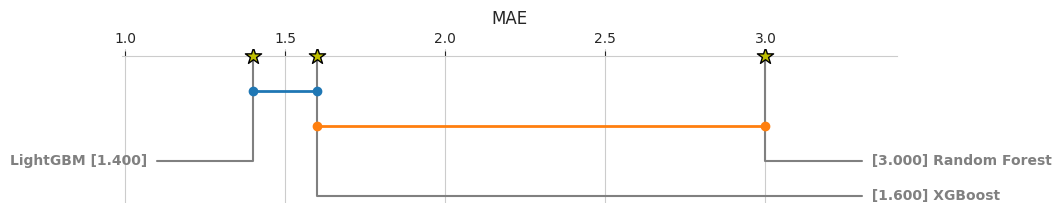

MSE
• Friedman p = 0.014996 → significativo
• Avg ranks: Random Forest: 2.80, XGBoost: 2.20, LightGBM: 1.00 



/usr/local/lib/python3.12/dist-packages/scikit_posthocs/_plotting.py:528: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (x for x in crossbar_sets if len(x) > 1), key=lambda x: ranks[list(x)].min()
/usr/local/lib/python3.12/dist-packages/scikit_posthocs/_plotting.py:549: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [ranks[i] for i in bar],


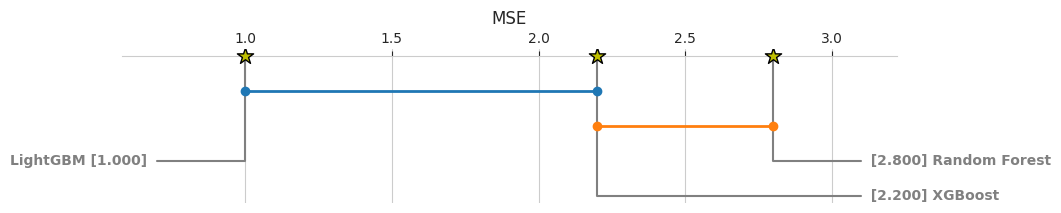

RMSE
• Friedman p = 0.014996 → significativo
• Avg ranks: Random Forest: 2.80, XGBoost: 2.20, LightGBM: 1.00 



/usr/local/lib/python3.12/dist-packages/scikit_posthocs/_plotting.py:528: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (x for x in crossbar_sets if len(x) > 1), key=lambda x: ranks[list(x)].min()
/usr/local/lib/python3.12/dist-packages/scikit_posthocs/_plotting.py:549: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [ranks[i] for i in bar],


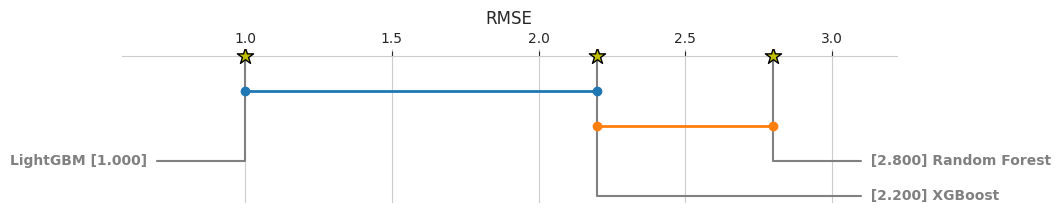

R²
• Friedman p = 0.014996 → significativo
• Avg ranks: Random Forest: 2.80, XGBoost: 2.20, LightGBM: 1.00 



/usr/local/lib/python3.12/dist-packages/scikit_posthocs/_plotting.py:528: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (x for x in crossbar_sets if len(x) > 1), key=lambda x: ranks[list(x)].min()
/usr/local/lib/python3.12/dist-packages/scikit_posthocs/_plotting.py:549: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [ranks[i] for i in bar],


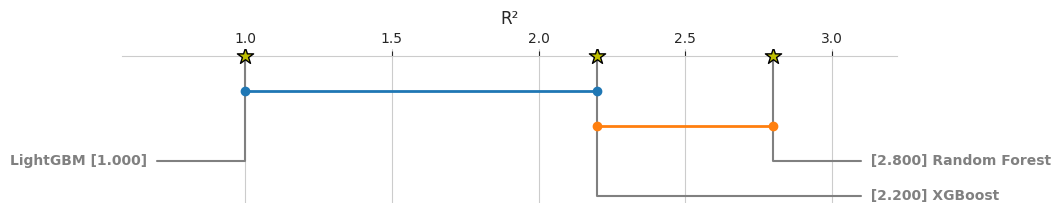

In [ ]:
models = {
    'LightGBM': {'MAE': maes_lgbm, 'MSE': mses_lgbm, 'RMSE': rmses_lgbm, 'R²': r2s_lgbm},
    'XGBoost': {'MAE': maes_xgb, 'MSE': mses_xgb, 'RMSE': rmses_xgb, 'R²': r2s_xgb},
    'Random Forest': {'MAE': maes_rf, 'MSE': mses_rf, 'RMSE': rmses_rf, 'R²': r2s_rf}
}

for metric in ['MAE','MSE','RMSE','R²']:
    data = np.array([models[m][metric] for m in ['Random Forest','XGBoost','LightGBM']]).T
    ranks = np.array([stats.rankdata(-row) if metric=='R²' else stats.rankdata(row) for row in data])
    avg_ranks = pd.Series(ranks.mean(axis=0), index=['Random Forest','XGBoost','LightGBM'])
    stat, p = friedmanchisquare(*[models[m][metric] for m in ['Random Forest','XGBoost','LightGBM']])

    print(f"{metric}")
    print(f"• Friedman p = {p:.6f} → {'significativo' if p<0.05 else 'não significativo'}")
    print("• Avg ranks: " + ", ".join(f"{k}: {v:.2f}" for k,v in avg_ranks.items()), "\n")

    if p < 0.05:
        test_results = sp.posthoc_nemenyi_friedman(data)
        plt.figure(figsize=(10,2))
        plt.title(metric)
        sp.critical_difference_diagram(avg_ranks, test_results, label_fmt_left='{label} [{rank:.3f}]  ',
    label_fmt_right='  [{rank:.3f}] {label}',
    text_h_margin=0.3,
    label_props={'fontweight': 'bold'},
    crossbar_props={'color': None, 'marker': 'o'},
    marker_props={'marker': '*', 's': 150, 'color': 'y', 'edgecolor': 'k'},
    elbow_props={'color': 'gray'},)
        plt.show()

#Análise de Resíduos

## Resíduos vs. Previsões

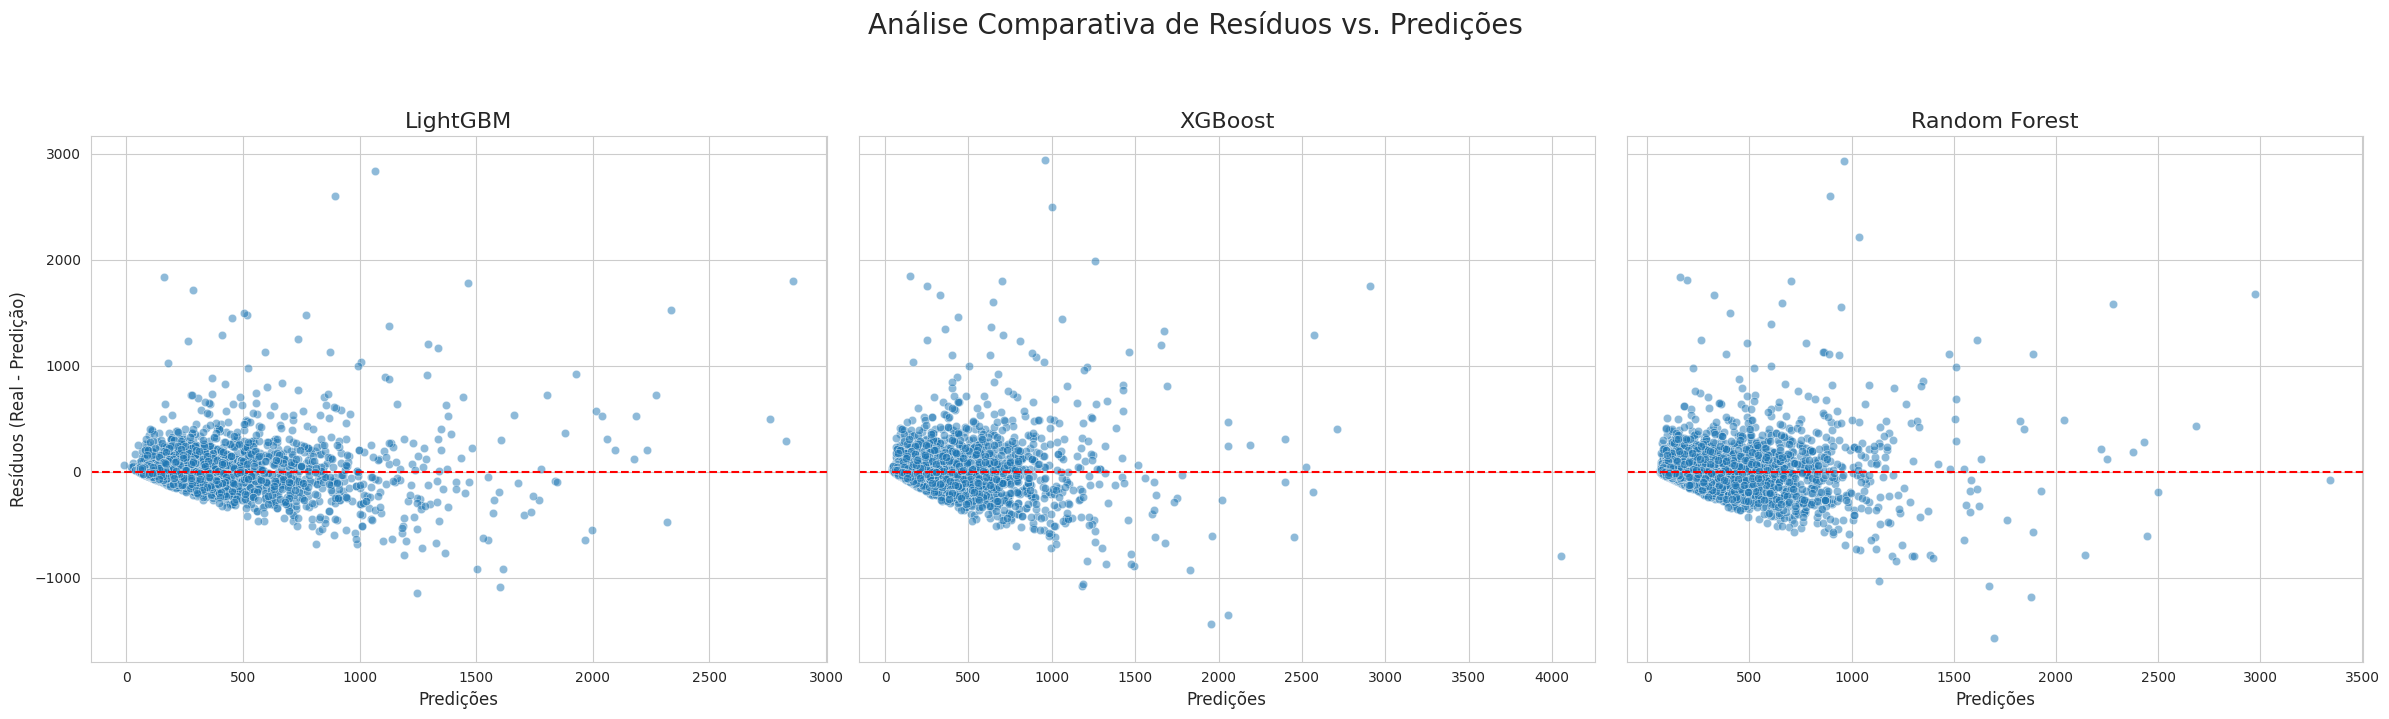

In [ ]:
y_true_all_folds = all_y_test_rf

residuals_rf = y_true_all_folds - all_predictions_rf
residuals_xgb = y_true_all_folds - all_predictions_xgb
residuals_lgbm = y_true_all_folds - all_predictions_lgbm

fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
fig.suptitle('Análise Comparativa de Resíduos vs. Predições', fontsize=20, y=1.02)

sns.scatterplot(x=all_predictions_lgbm, y=residuals_lgbm, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('LightGBM', fontsize=16)
axes[0].set_xlabel('Predições', fontsize=12)
axes[0].set_ylabel('Resíduos (Real - Predição)', fontsize=12)

sns.scatterplot(x=all_predictions_xgb, y=residuals_xgb, alpha=0.5, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('XGBoost', fontsize=16)
axes[1].set_xlabel('Predições', fontsize=12)
axes[1].set_ylabel('')

sns.scatterplot(x=all_predictions_rf, y=residuals_rf, alpha=0.5, ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Random Forest', fontsize=16)
axes[2].set_xlabel('Predições', fontsize=12)
axes[2].set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Resíduos vs. Valores Reais

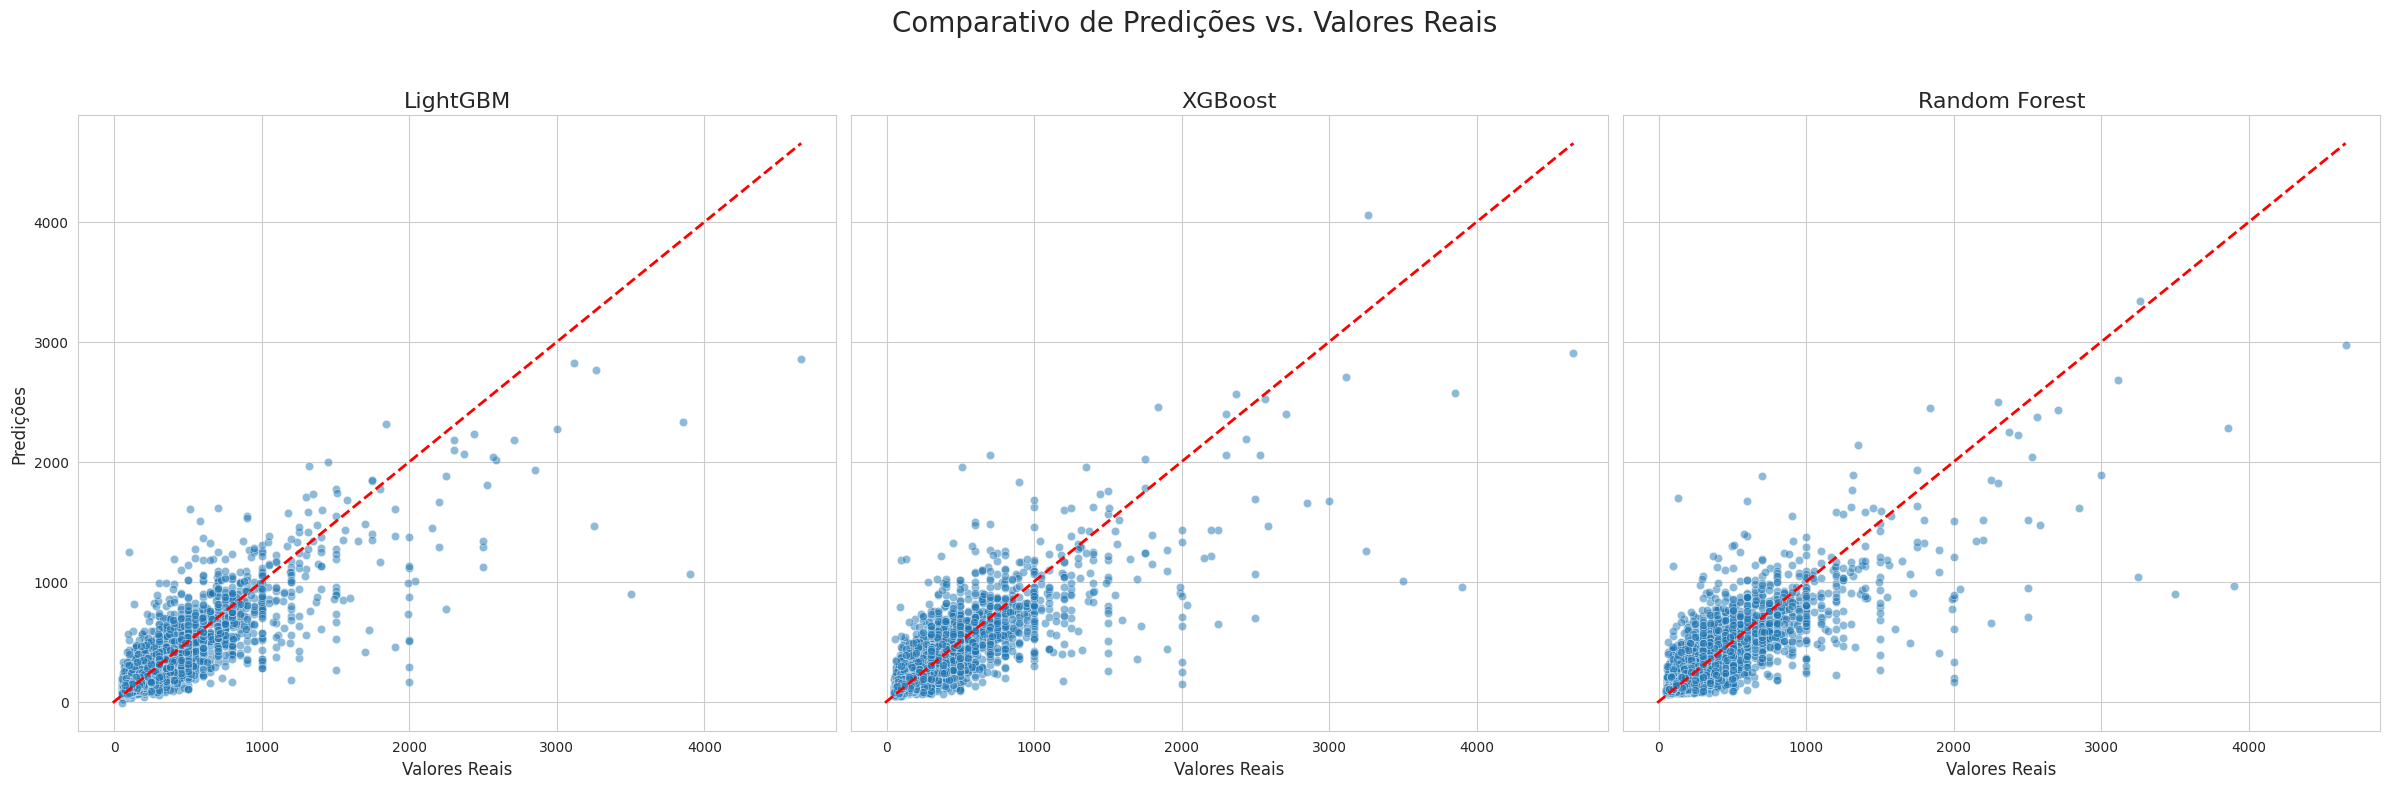

In [ ]:
y_true_all_folds = all_y_test_rf

min_val = min(y_true_all_folds.min(), all_predictions_lgbm.min(), all_predictions_xgb.min(), all_predictions_rf.min())
max_val = max(y_true_all_folds.max(), all_predictions_lgbm.max(), all_predictions_xgb.max(), all_predictions_rf.max())

fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)
fig.suptitle('Comparativo de Predições vs. Valores Reais', fontsize=20, y=0.98)

sns.scatterplot(x=y_true_all_folds, y=all_predictions_lgbm, alpha=0.5, ax=axes[0])
axes[0].plot([min_val, max_val], [min_val, max_val], '--', color='red', linewidth=2)
axes[0].set_title('LightGBM', fontsize=16)
axes[0].set_xlabel('Valores Reais', fontsize=12)
axes[0].set_ylabel('Predições', fontsize=12)
axes[0].grid(True)

sns.scatterplot(x=y_true_all_folds, y=all_predictions_xgb, alpha=0.5, ax=axes[1])
axes[1].plot([min_val, max_val], [min_val, max_val], '--', color='red', linewidth=2)
axes[1].set_title('XGBoost', fontsize=16)
axes[1].set_xlabel('Valores Reais', fontsize=12)
axes[1].set_ylabel('');
axes[1].grid(True)

sns.scatterplot(x=y_true_all_folds, y=all_predictions_rf, alpha=0.5, ax=axes[2])
axes[2].plot([min_val, max_val], [min_val, max_val], '--', color='red', linewidth=2)
axes[2].set_title('Random Forest', fontsize=16)
axes[2].set_xlabel('Valores Reais', fontsize=12)
axes[2].set_ylabel('');
axes[2].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Comparação entre os modelos (Métricas computacionais)

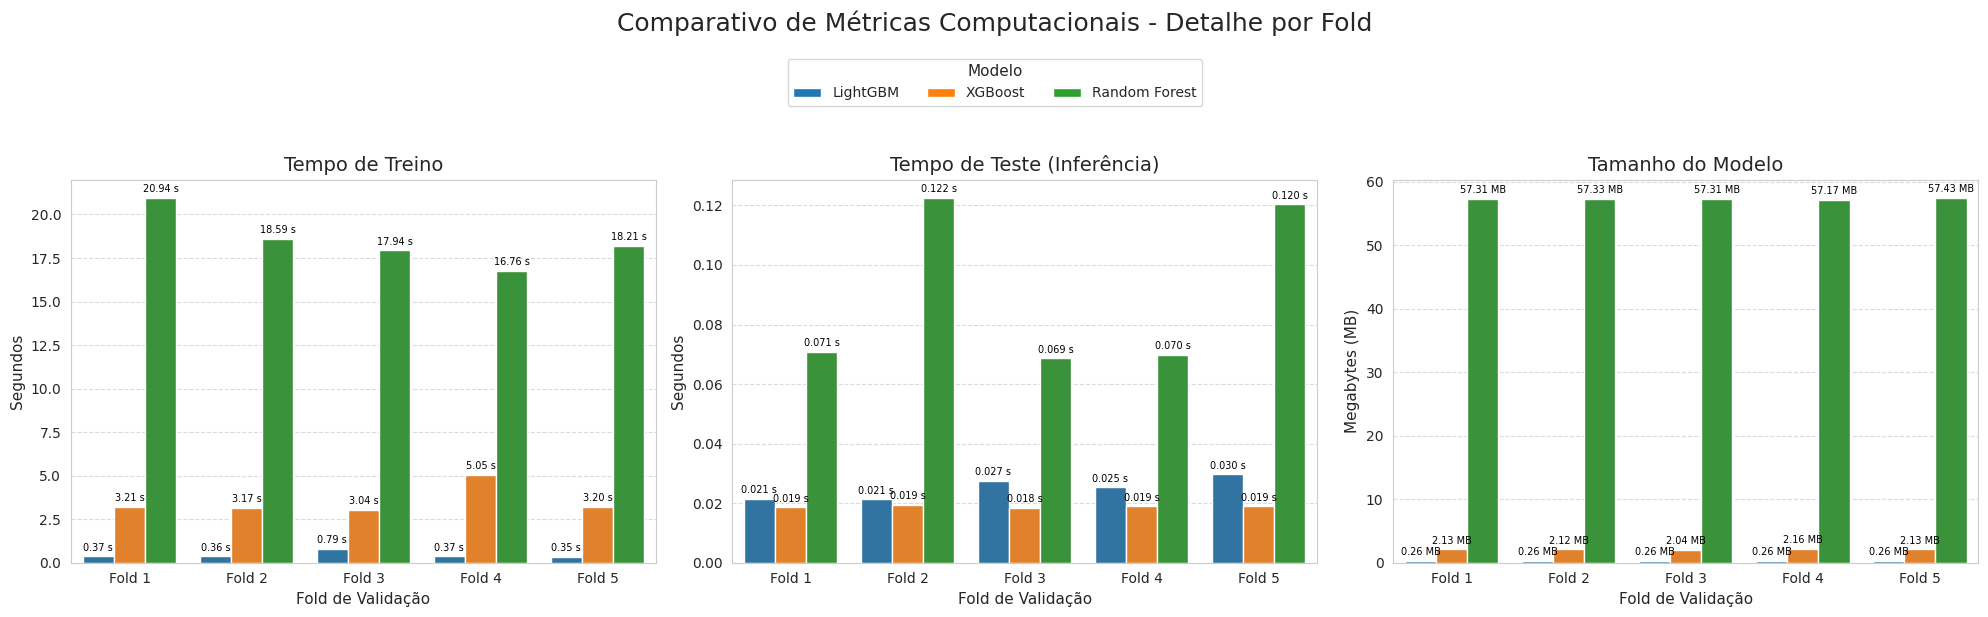

In [ ]:
from matplotlib.patches import Patch

models = ['LightGBM', 'XGBoost', 'Random Forest']


results_map = {
    'Tempo_Treino': {'LightGBM': train_times_lgbm, 'XGBoost': train_times_xgb, 'Random Forest': train_times_rf},
    'Tempo_Teste': {'LightGBM': test_times_lgbm, 'XGBoost': test_times_xgb, 'Random Forest': test_times_rf},
    'Tamanho': {'LightGBM': model_sizes_lgbm, 'XGBoost': model_sizes_xgb, 'Random Forest': model_sizes_rf},
}
num_folds = len(results_map['Tempo_Treino']['LightGBM'])
MODEL_PALETTE = {'LightGBM': '#1f77b4', 'XGBoost': '#ff7f0e', 'Random Forest': '#2ca02c'}

data_list = []
for model_name in models:
    for i in range(num_folds):
        data_list.append({
            'Fold': f'Fold {i+1}',
            'Modelo': model_name,
            'Tempo_Treino': results_map['Tempo_Treino'][model_name][i],
            'Tempo_Teste': results_map['Tempo_Teste'][model_name][i],
            'Tamanho': results_map['Tamanho'][model_name][i],
        })
df_data_for_plot = pd.DataFrame(data_list)


def plot_fold_barplot(ax, data, metric, title, ylabel, palette, fmt_string, order=None):

    sns.barplot(
        x='Fold',
        y=metric,
        hue='Modelo',
        data=data,
        order=[f'Fold {i+1}' for i in range(num_folds)],
        ax=ax,
        palette=palette,
        errorbar=None,
        legend=False
    )

    ax.set_title(title, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('Fold de Validação', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + (df_data_for_plot[metric].max() * 0.01),
            fmt_string.format(height),
            ha='center',
            va='bottom',
            fontsize=7,
            color='black'
        )

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comparativo de Métricas Computacionais - Detalhe por Fold', fontsize=18, y=1.05)


plot_fold_barplot(
    axes[0], df_data_for_plot, 'Tempo_Treino', 'Tempo de Treino',
    'Segundos', MODEL_PALETTE, '{:.2f} s', order=models)

plot_fold_barplot(
    axes[1], df_data_for_plot, 'Tempo_Teste', 'Tempo de Teste (Inferência)',
    'Segundos', MODEL_PALETTE, '{:.3f} s', order=models)

plot_fold_barplot(
    axes[2], df_data_for_plot, 'Tamanho', 'Tamanho do Modelo',
    'Megabytes (MB)', MODEL_PALETTE, '{:.2f} MB', order=models)


legend_handles = [Patch(facecolor=MODEL_PALETTE[m], label=m) for m in models]
fig.legend(
    handles=legend_handles,
    title='Modelo',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

# Análise de importância das features

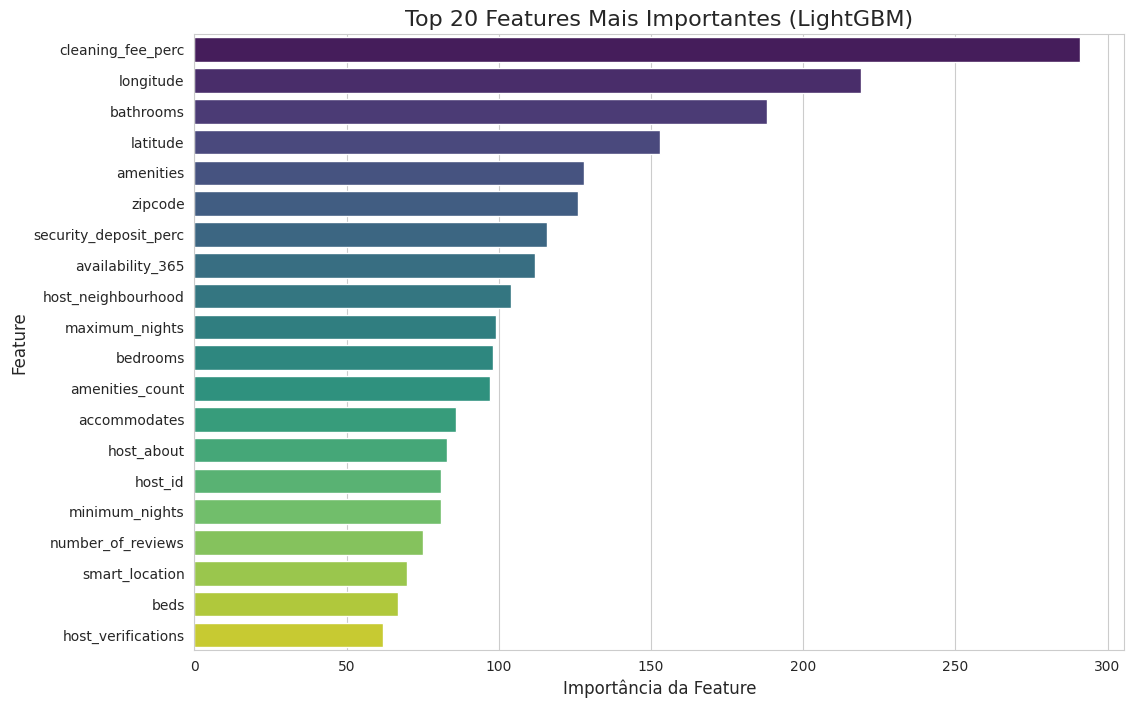

In [ ]:
feature_importances = pd.Series(model_lgbm.feature_importances_, index=X_test.columns)

top_features = feature_importances.nlargest(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', hue=top_features.index, legend=False)
plt.title('Top 20 Features Mais Importantes (LightGBM)', fontsize=16)
plt.xlabel('Importância da Feature', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()

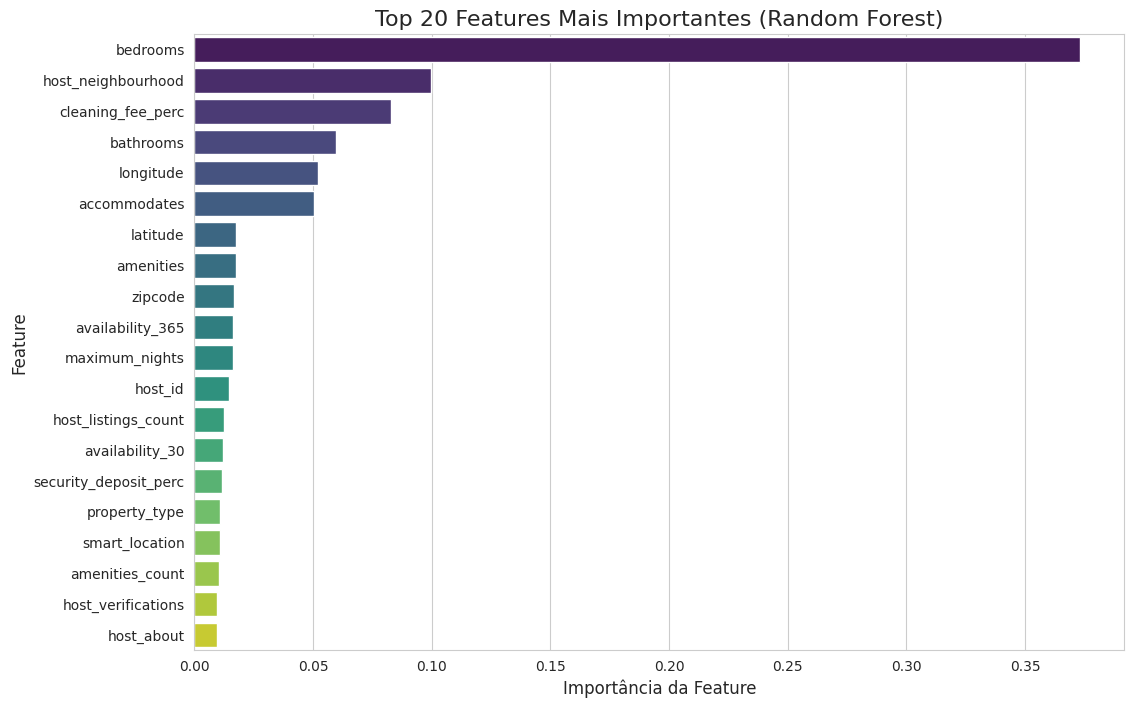

In [ ]:
feature_importances = pd.Series(model_rf.feature_importances_, index=X_test.columns)

top_features = feature_importances.nlargest(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', hue=top_features.index, legend=False)
plt.title('Top 20 Features Mais Importantes (Random Forest)', fontsize=16)
plt.xlabel('Importância da Feature', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()

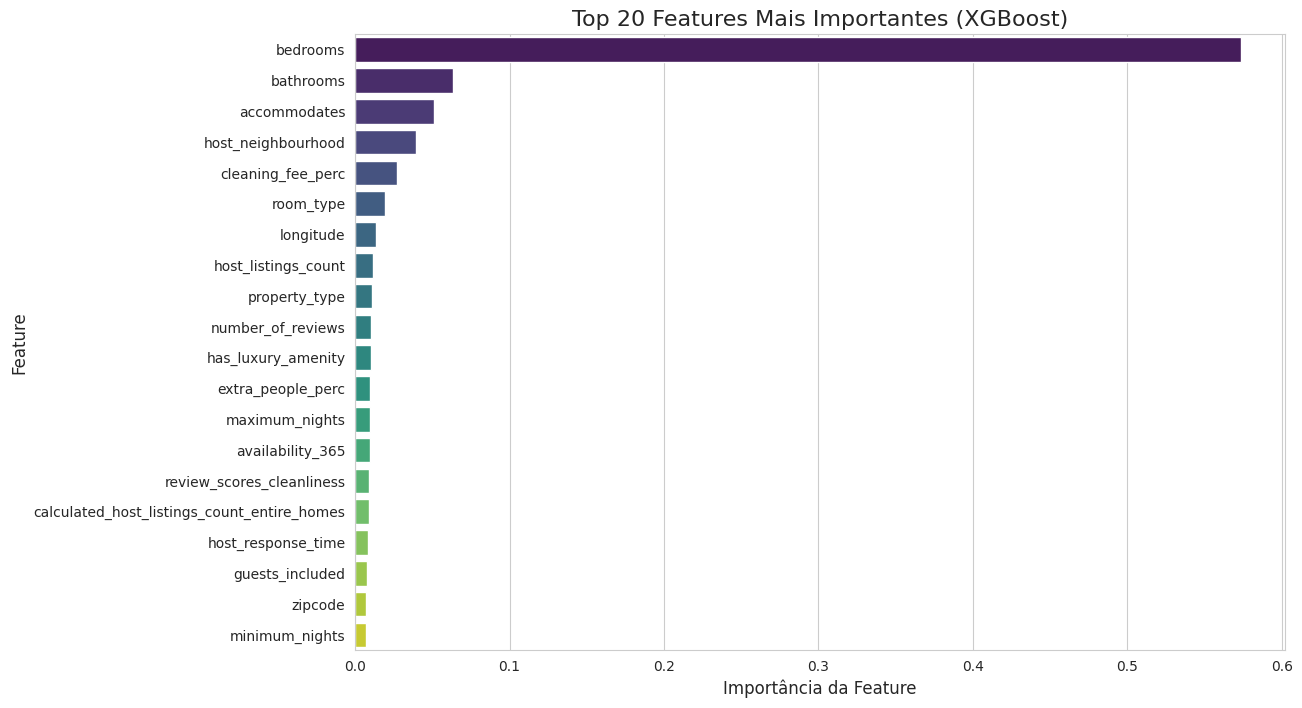

In [ ]:
feature_importances = pd.Series(model_xgb.feature_importances_, index=X_test.columns)

top_features = feature_importances.nlargest(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', hue=top_features.index, legend=False)
plt.title('Top 20 Features Mais Importantes (XGBoost)', fontsize=16)
plt.xlabel('Importância da Feature', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()